<a href="https://colab.research.google.com/github/PuspitaHelal/Thesis_code/blob/main/%F0%9F%98%AB%F0%9F%98%AB%F0%9F%98%ABanxiety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
puspitahelal_public_private_university_student_path = kagglehub.dataset_download('puspitahelal/public-private-university-student')

print('Data source import complete.')


100%|██████████| 188k/188k [00:00<00:00, 390kB/s]

Extracting files...
Data source import complete.


In [2]:
import numpy as np
import pandas as pd


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Import Libraries

In [4]:
# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
!pip install catboost -qq
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


# Load Data

In [6]:
import os
import pandas as pd

# Use the path provided by kagglehub.dataset_download
# The actual files are within the 'versions/1' subdirectory of the downloaded path
dataset_directory = puspitahelal_public_private_university_student_path

# List files in the actual dataset directory to confirm
print(f"Files in dataset directory: {os.listdir(dataset_directory)}")

# Construct the full path to Processed.csv
DATA_PATH = os.path.join(dataset_directory, "Processed.csv")
df = pd.read_csv(DATA_PATH)
df.head(10)

Files in dataset directory: ['Processed.csv', 'Stress.csv', 'Anxiety.csv', 'Depression.csv', 'Raw Dataset.csv']


,Age,Gender,University,Department,Academic_Year,Current_CGPA,waiver_or_scholarship,PSS1,PSS2,PSS3,...,PHQ2,PHQ3,PHQ4,PHQ5,PHQ6,PHQ7,PHQ8,PHQ9,Depression Value,Depression Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,4,3,...,2,3,2,2,2,2,3,2,20,Severe Depression
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,3,3,4,...,2,2,2,2,2,2,2,2,19,Moderately Severe Depression
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,...,0,0,0,0,0,0,0,0,0,No Depression
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,3,1,2,...,1,2,1,2,1,2,2,1,14,Moderate Depression
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,4,4,4,...,3,3,3,1,3,0,3,3,20,Severe Depression
5,23-26,Male,Islamic University of Technology (IUT),Engineering - CS / CSE / CSC / Similar to CS,Other,3.00 - 3.39,No,1,1,1,...,1,1,2,2,1,2,0,0,10,Moderate Depression
6,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,No,2,2,2,...,0,0,1,0,0,0,1,0,3,Minimal Depression
7,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - EEE/ ECE / Similar to EEE,First Year or Equivalent,3.00 - 3.39,No,0,0,0,...,0,0,2,0,0,1,0,0,3,Minimal Depression
8,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,2,3,2,...,3,2,1,2,3,2,1,2,19,Moderately Severe Depression
9,18-22,Male,Islamic University of Technology (IUT),Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.40 - 3.79,No,2,2,3,...,0,0,1,0,0,0,0,0,2,Minimal Depression


# EDA

In [ ]:
# Step 1: Statistical Overview

# Basic info
print(df.info())

# Summary statistics for both numeric and categorical
print(df.describe(include="all").T)

# Define numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Skewness and kurtosis for numeric features
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurt()

print("Skewness:\n", skewness)
print("Kurtosis:\n", kurtosis)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:\n", missing)


# Missing values
print("Missing values per column:\n", df.isnull().sum())


===== DATA LOADED SUCCESSFULLY =====

===== DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2028 entries, 0 to 2027
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    2028 non-null   object
 1   Gender                 2028 non-null   object
 2   University             2028 non-null   object
 3   Department             2028 non-null   object
 4   Academic_Year          2028 non-null   object
 5   Current_CGPA           2028 non-null   object
 6   waiver_or_scholarship  2028 non-null   object
 7   PSS1                   2028 non-null   int64 
 8   PSS2                   2028 non-null   int64 
 9   PSS3                   2028 non-null   int64 
 10  PSS4                   2028 non-null   int64 
 11  PSS5                   2028 non-null   int64 
 12  PSS6                   2028 non-null   int64 
 13  PSS7                   2028 non-null   int64 
 14  PSS8       

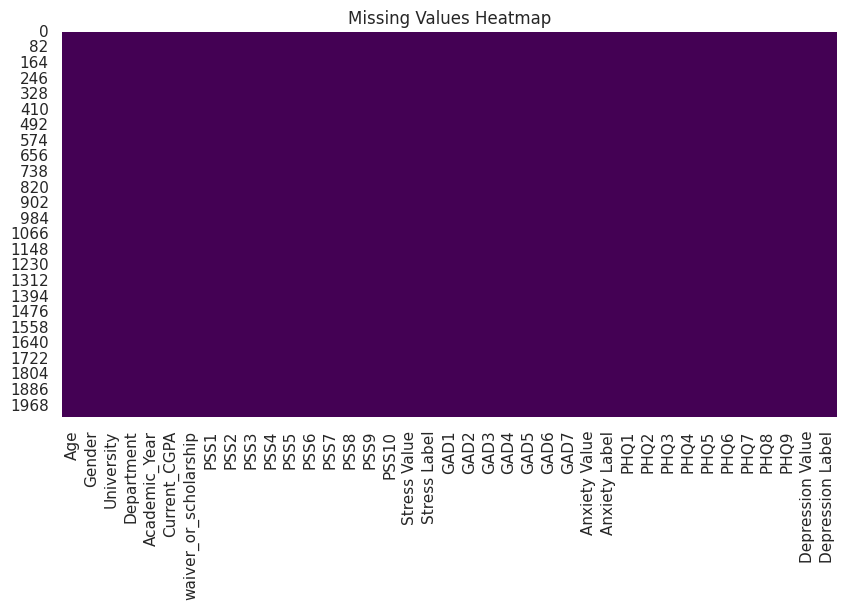


Duplicate Rows: 6

===== SKEWNESS =====
PSS1               -0.242939
PSS2               -0.177377
PSS3               -0.446660
PSS4               -0.246052
PSS5               -0.101224
PSS6                0.058648
PSS7               -0.057383
PSS8                0.113642
PSS9               -0.220926
PSS10              -0.214443
Stress Value        0.313700
GAD1               -0.217433
GAD2               -0.045128
GAD3               -0.167807
GAD4               -0.170018
GAD5               -0.307620
GAD6               -0.224876
GAD7               -0.168530
Anxiety Value      -0.213974
PHQ1                0.195804
PHQ2               -0.225309
PHQ3               -0.108930
PHQ4               -0.410279
PHQ5                0.090996
PHQ6               -0.264628
PHQ7               -0.053975
PHQ8                0.166249
PHQ9                0.444907
Depression Value   -0.056488
dtype: float64

===== KURTOSIS =====
PSS1               -0.602995
PSS2               -0.630610
PSS3               -0.5

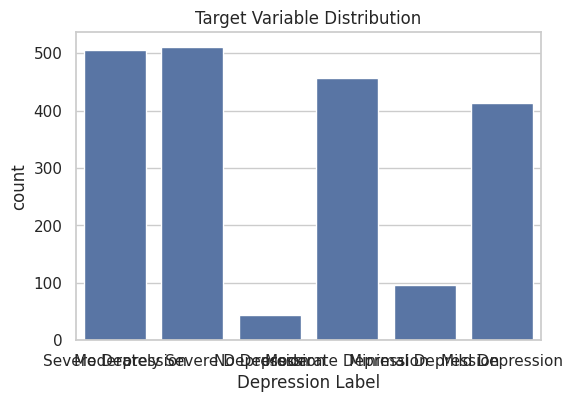


===== TARGET PERCENTAGE =====
Depression Label
Moderately Severe Depression    25.197239
Severe Depression               24.901381
Moderate Depression             22.534517
Mild Depression                 20.414201
Minimal Depression               4.783037
No Depression                    2.169625
Name: proportion, dtype: float64


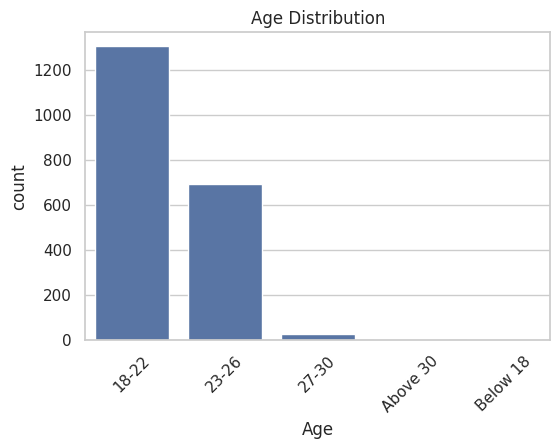

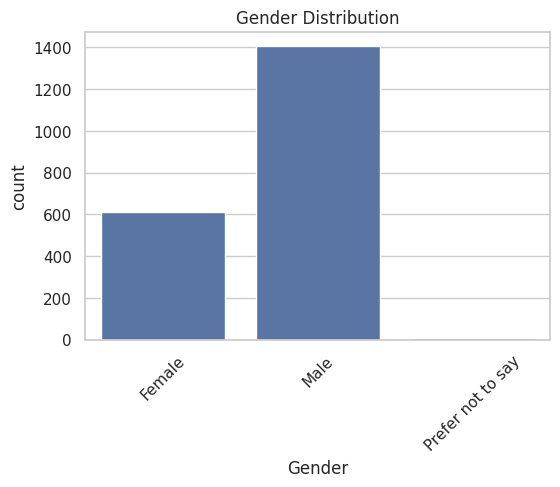

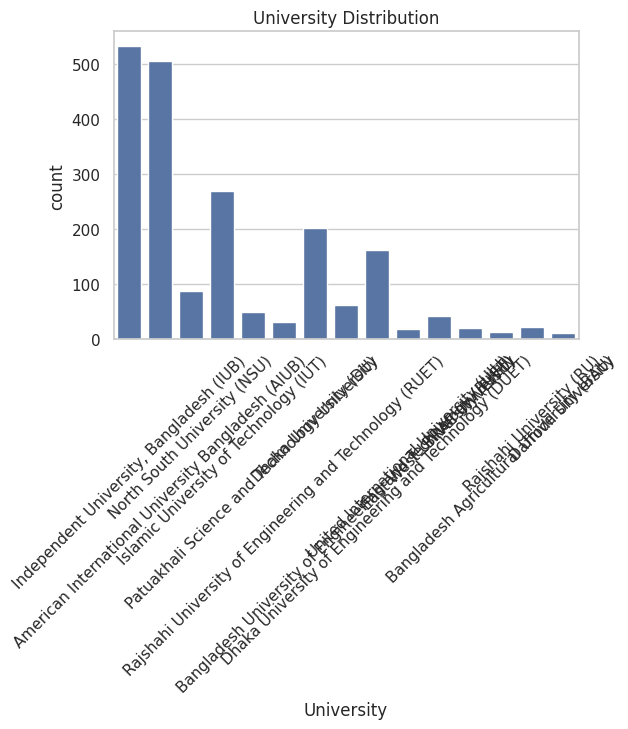

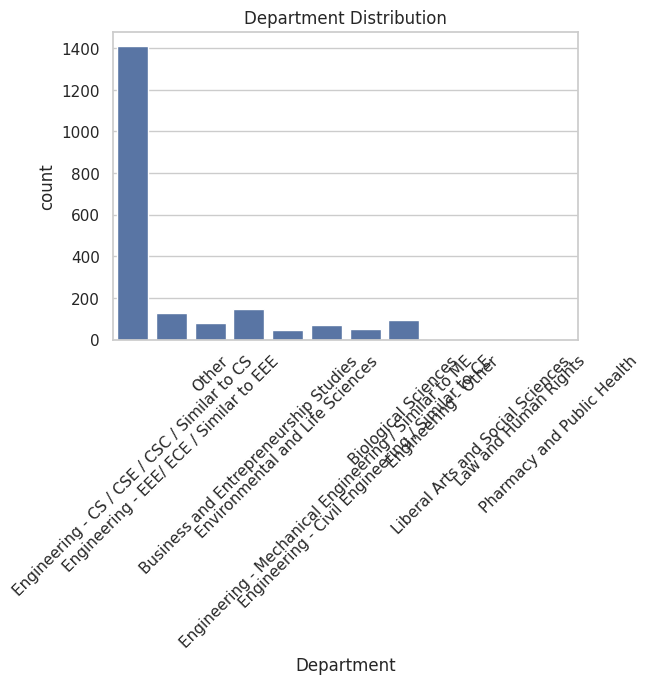

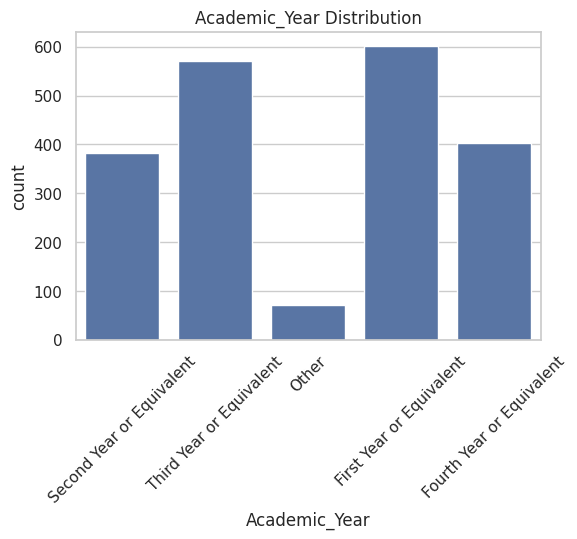

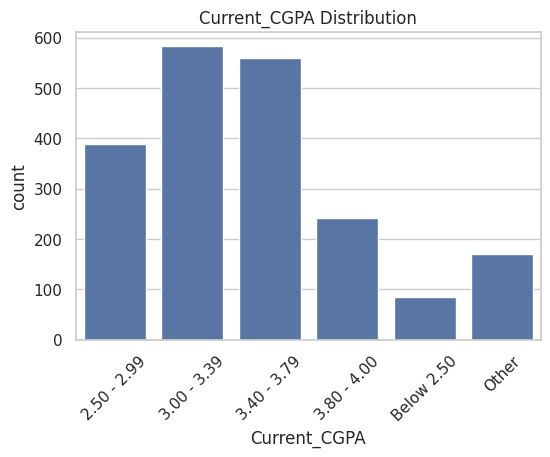

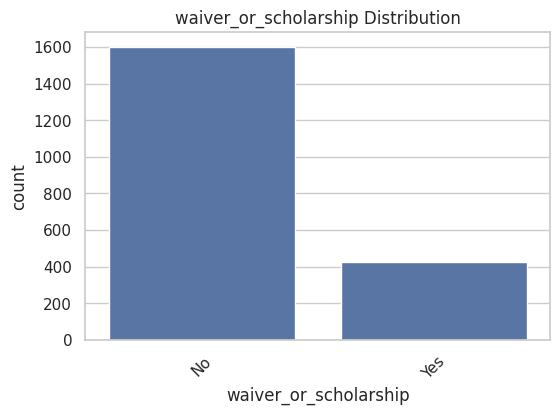

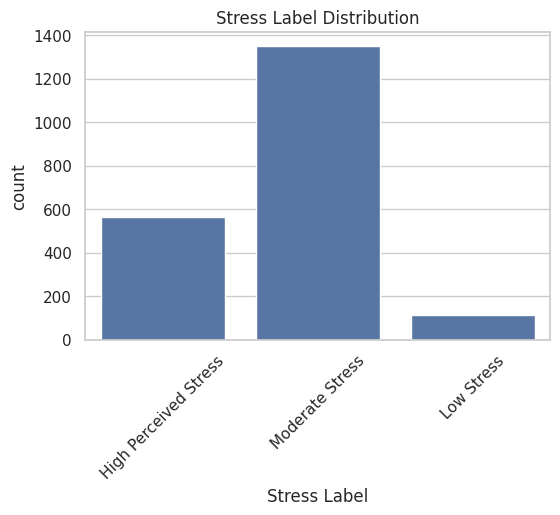

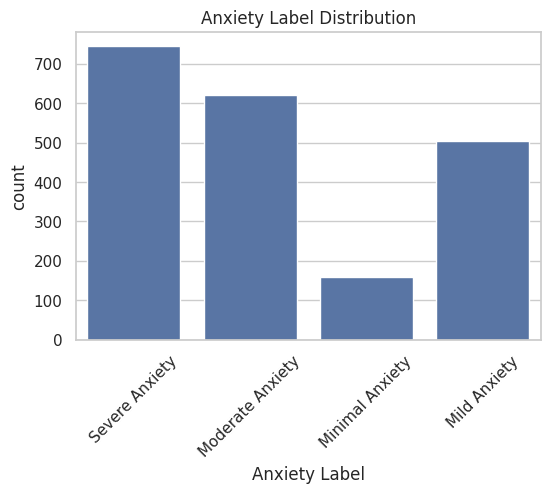

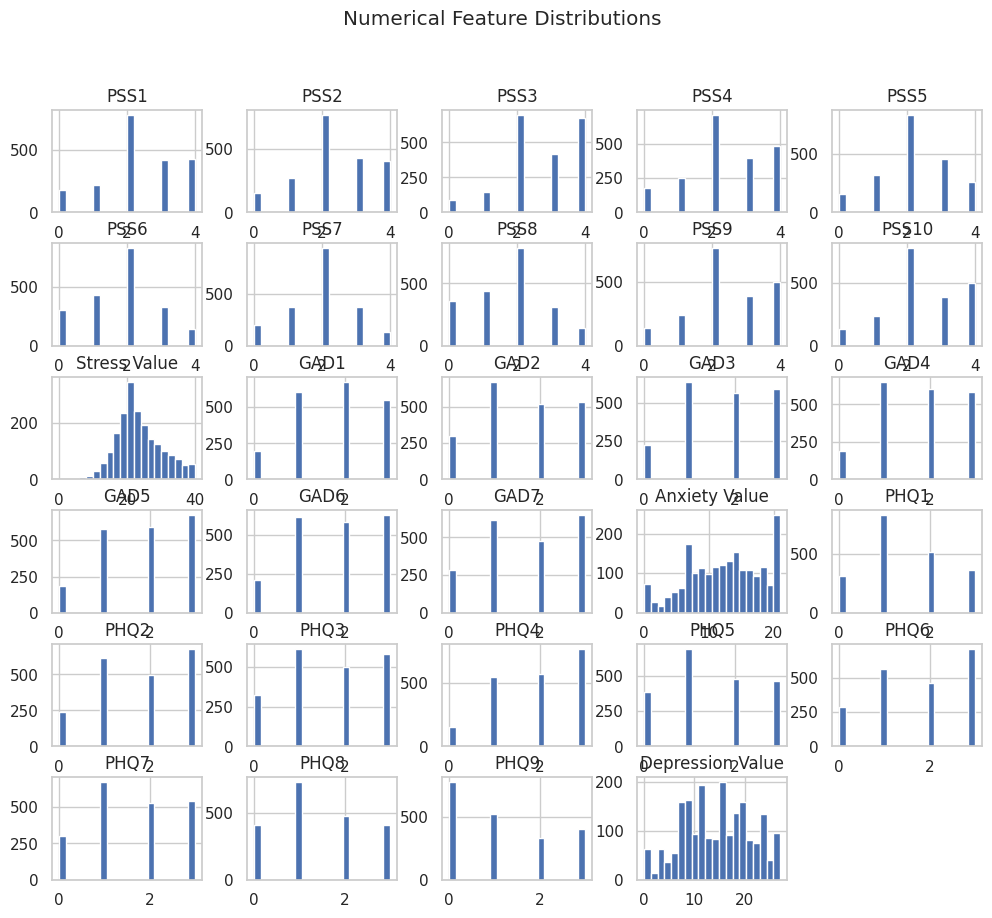

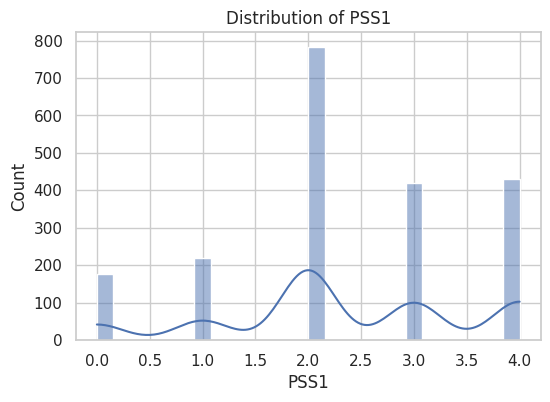

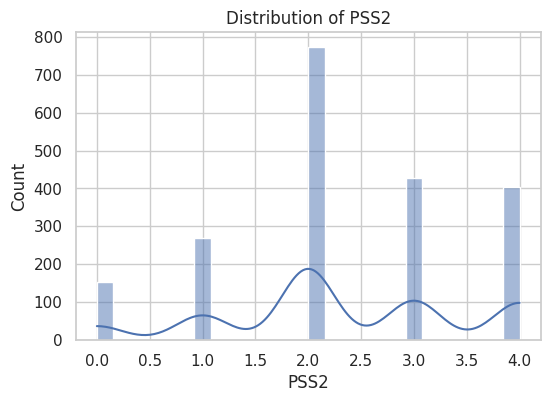

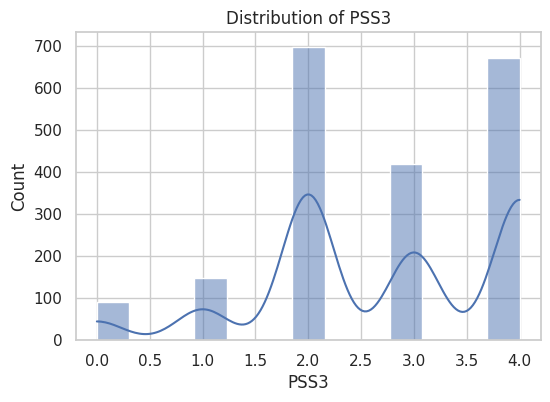

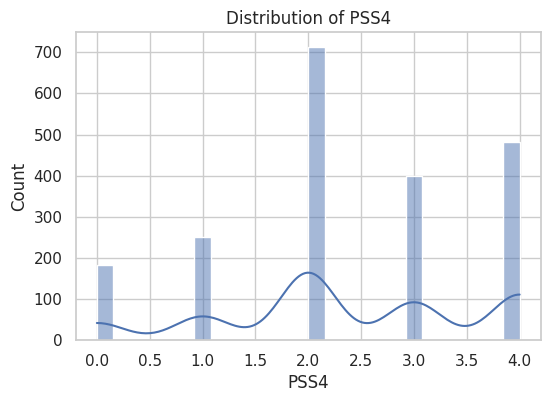

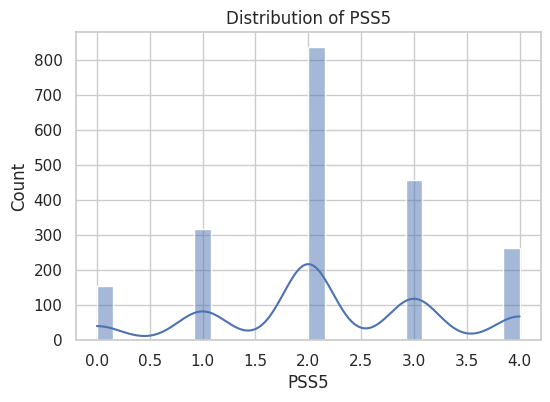

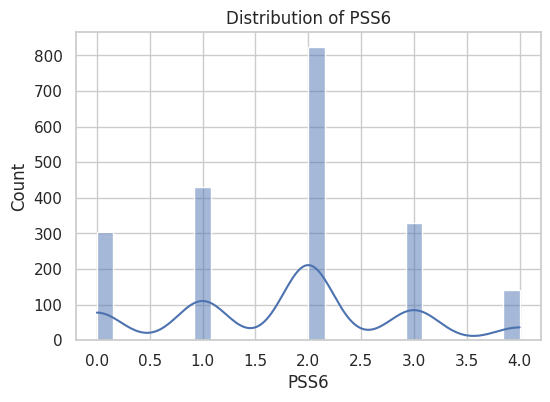

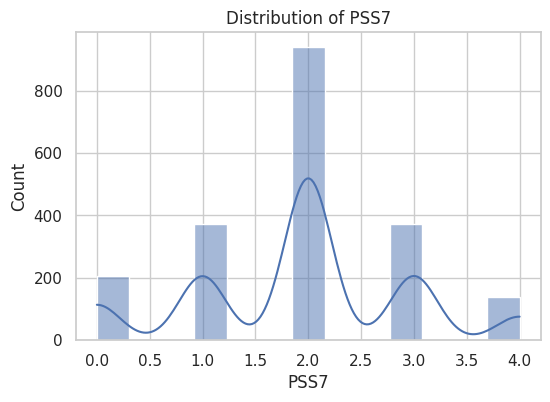

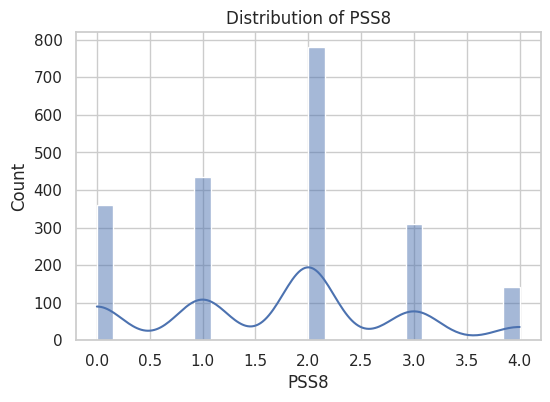

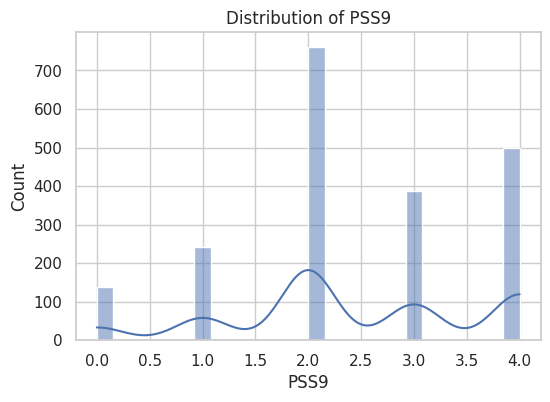

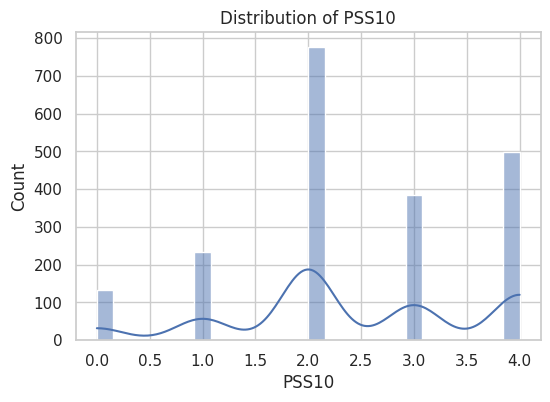

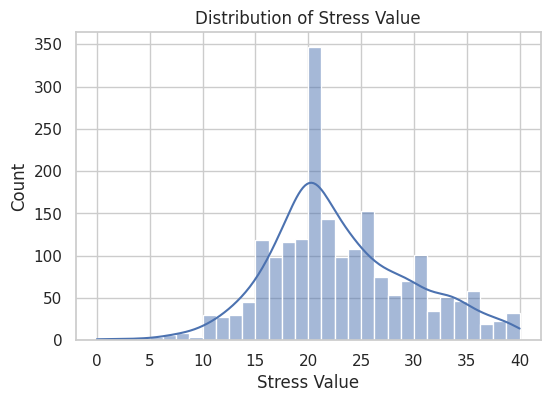

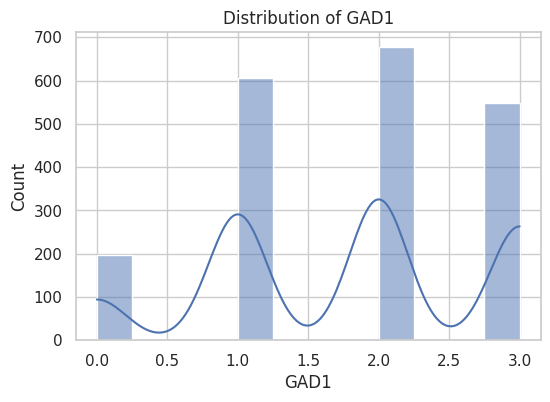

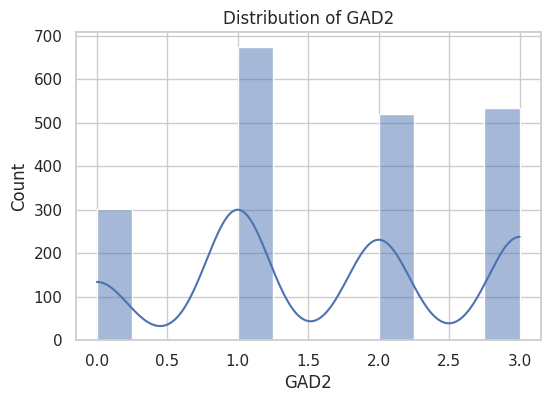

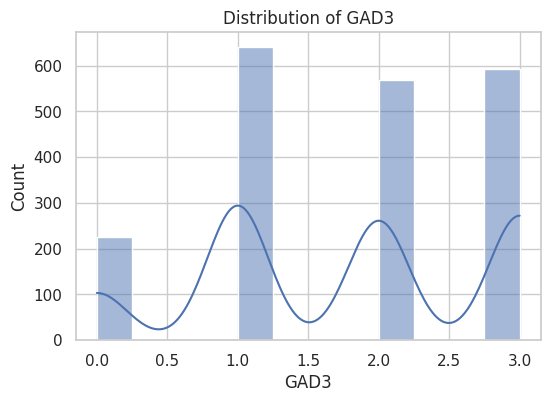

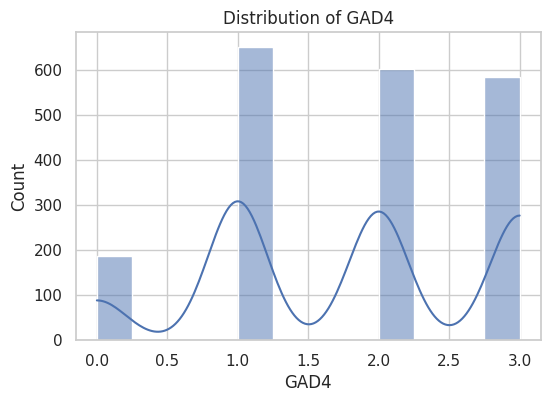

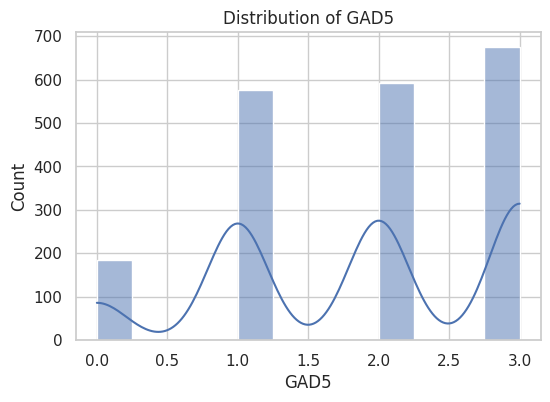

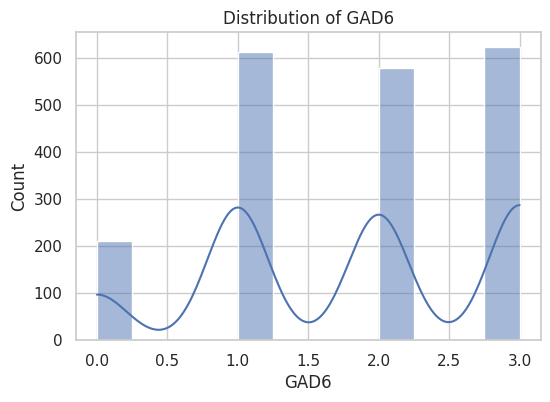

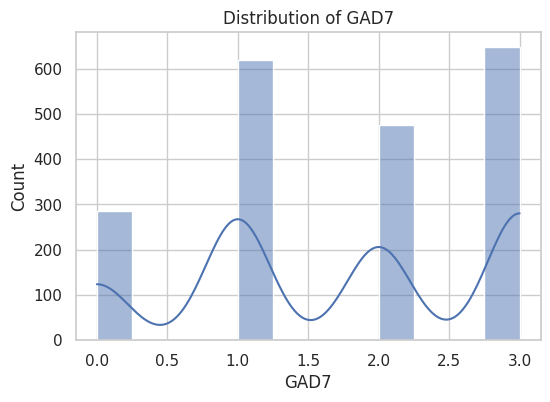

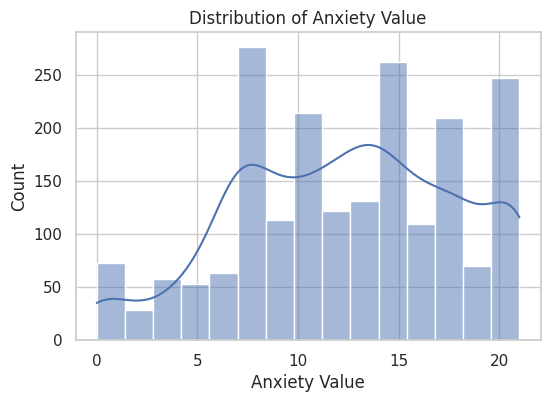

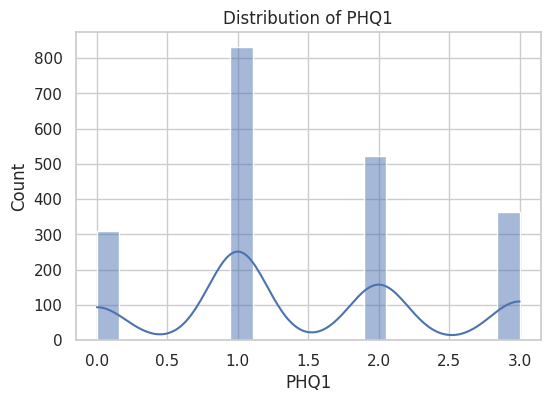

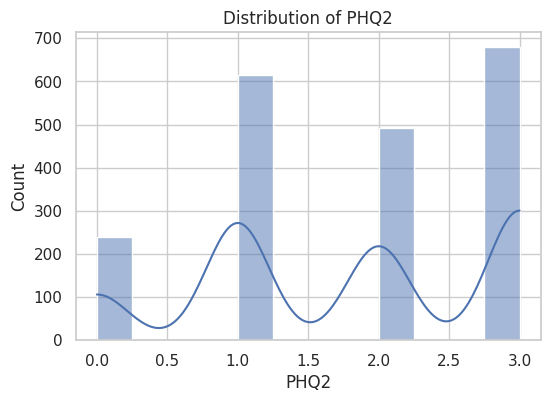

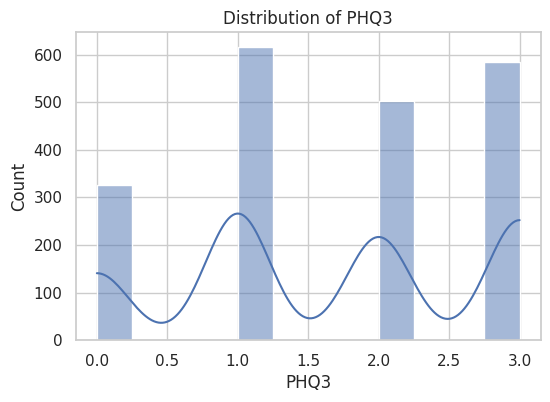

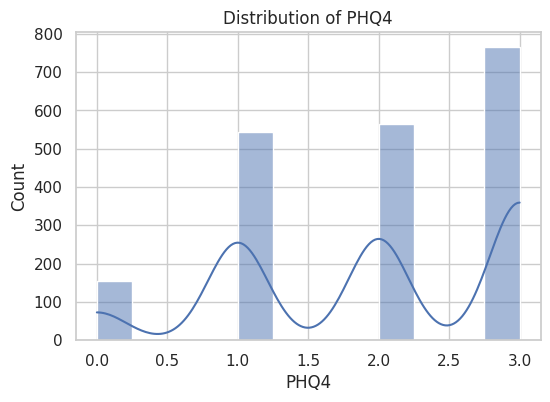

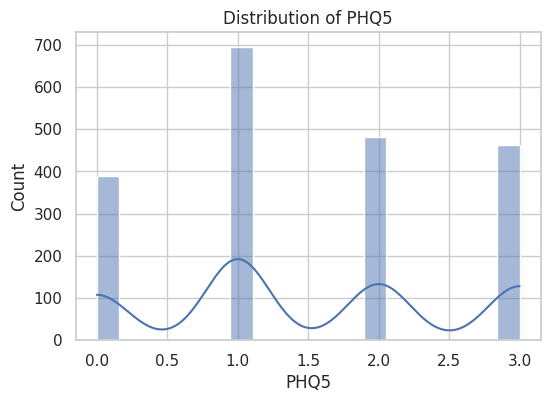

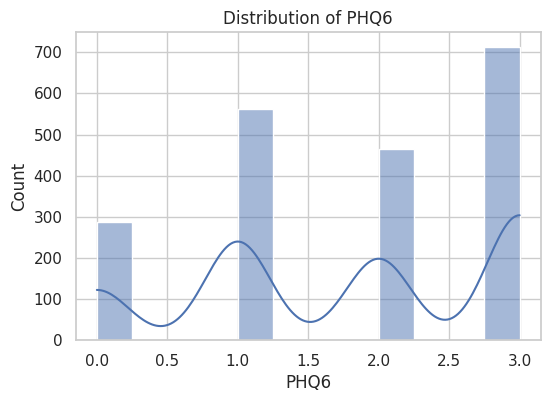

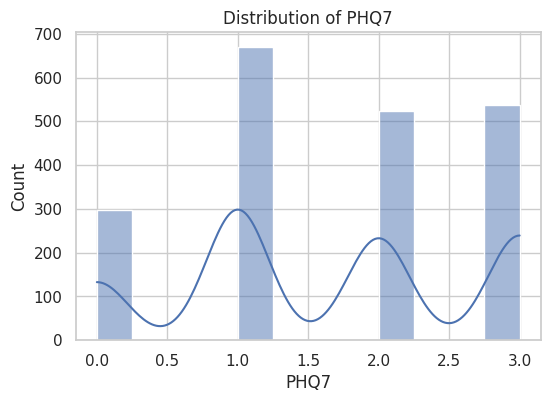

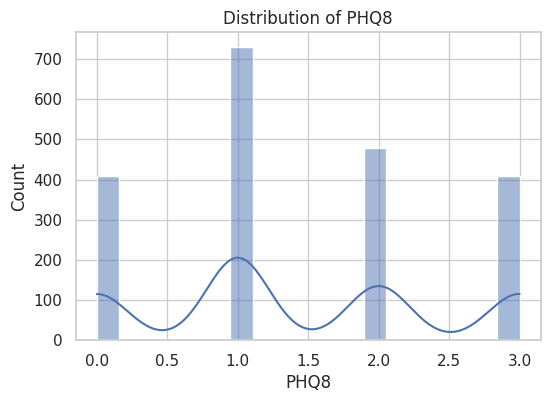

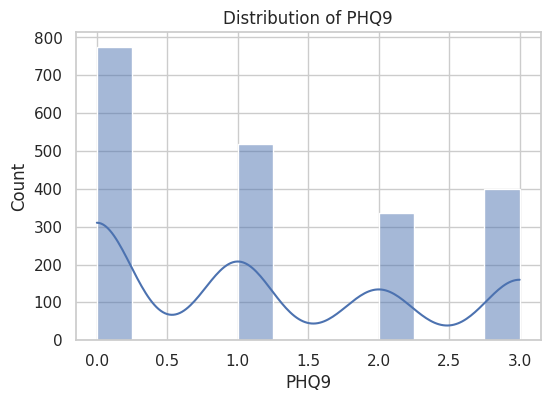

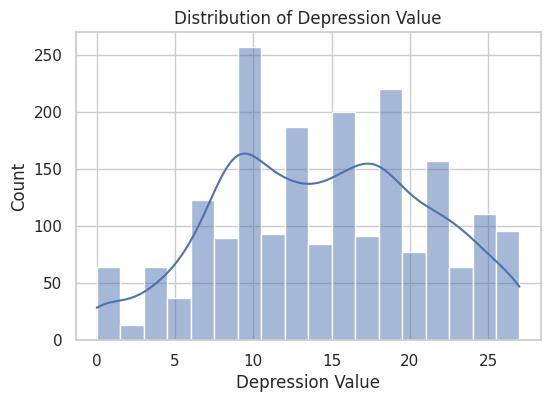

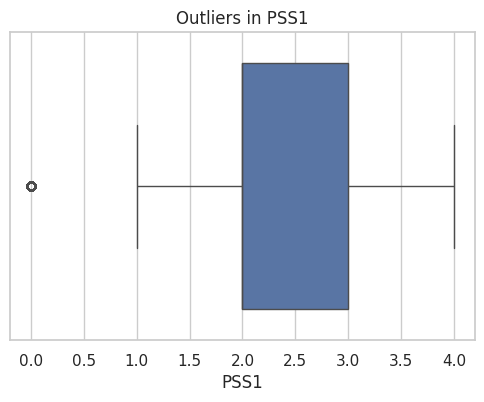

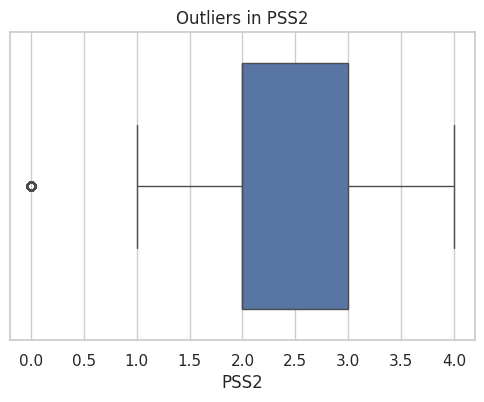

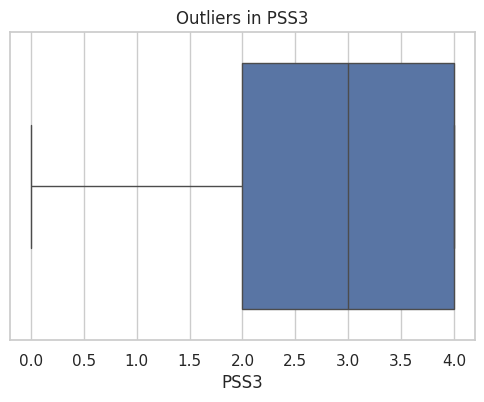

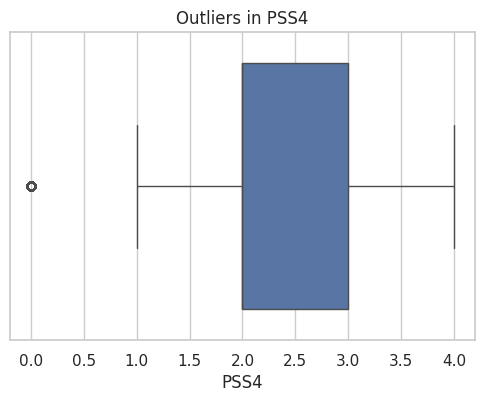

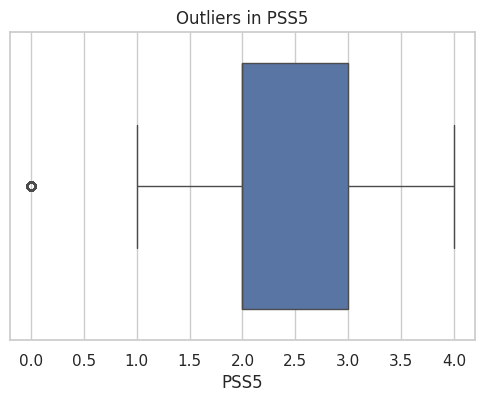

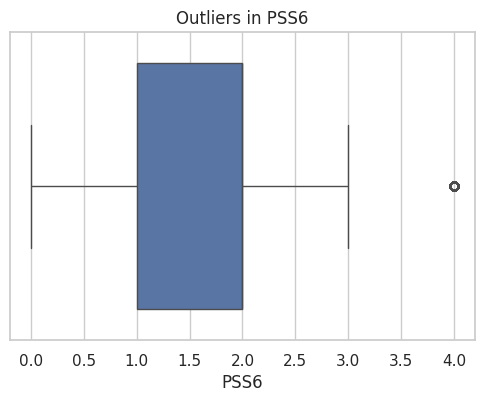

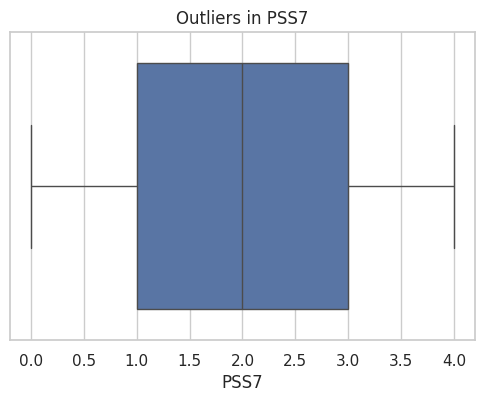

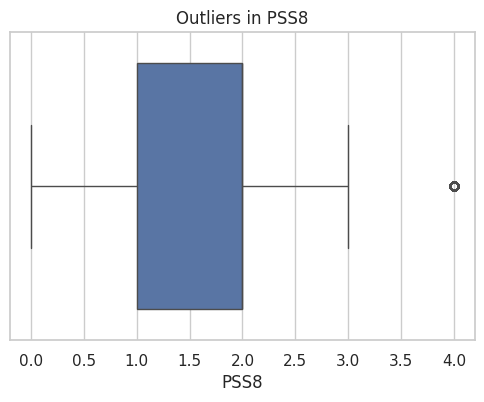

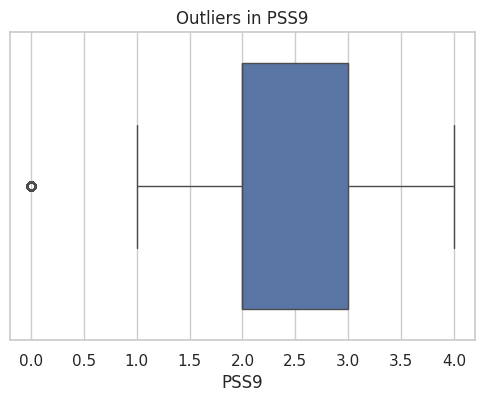

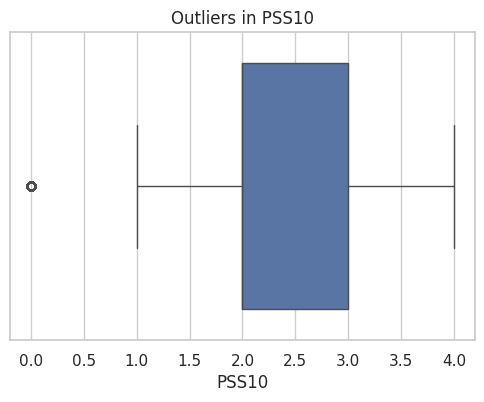

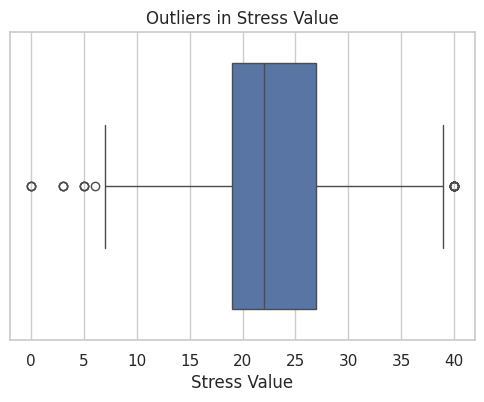

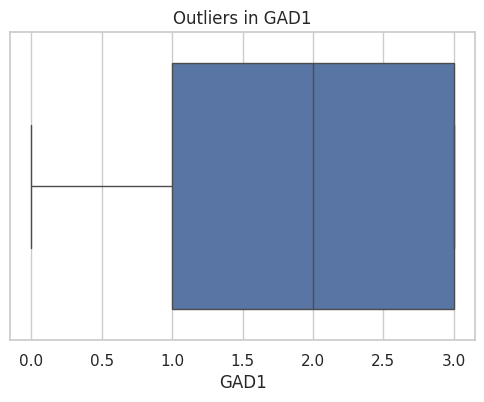

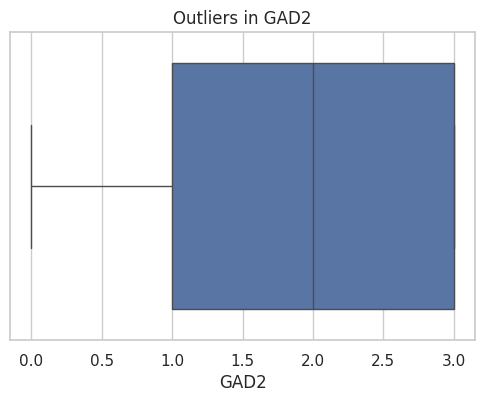

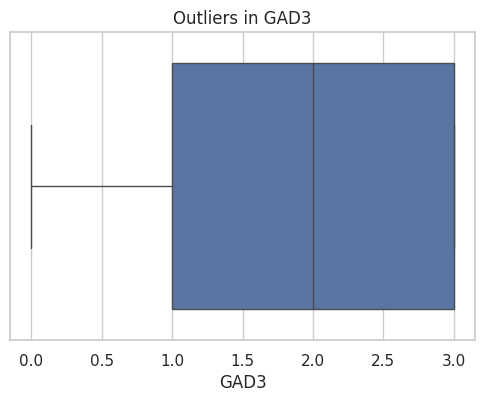

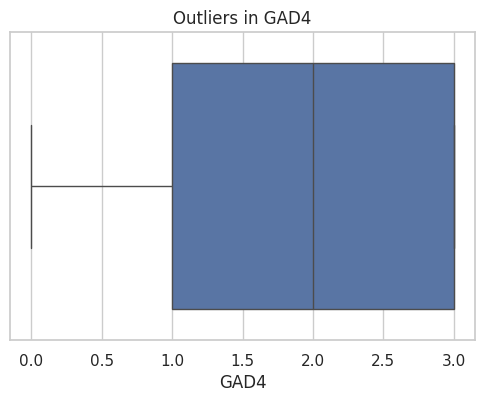

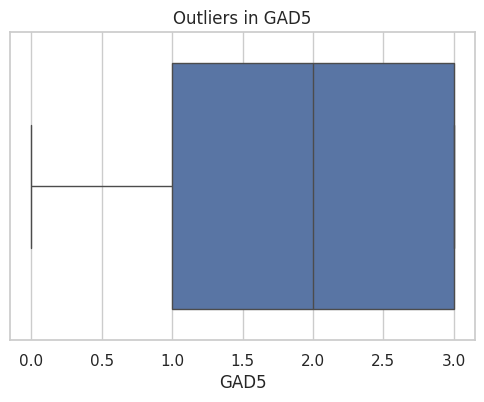

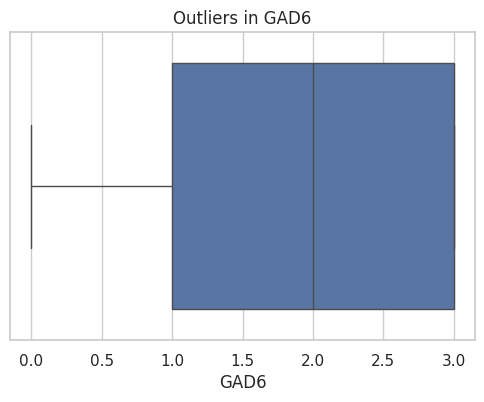

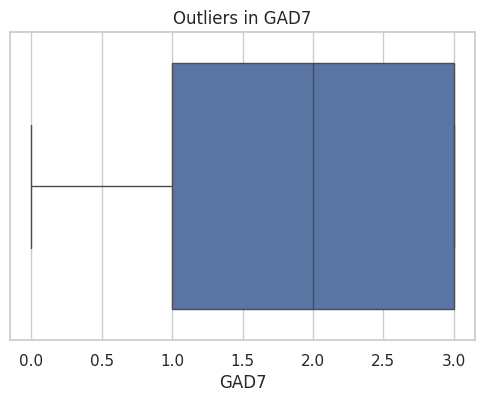

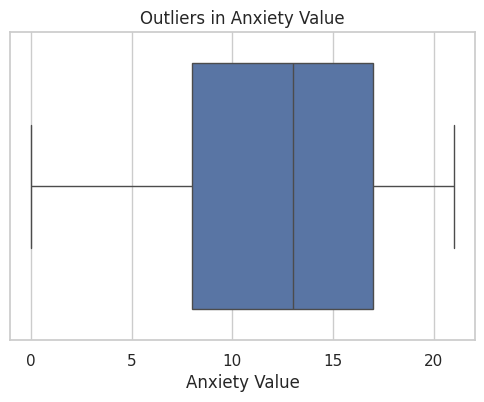

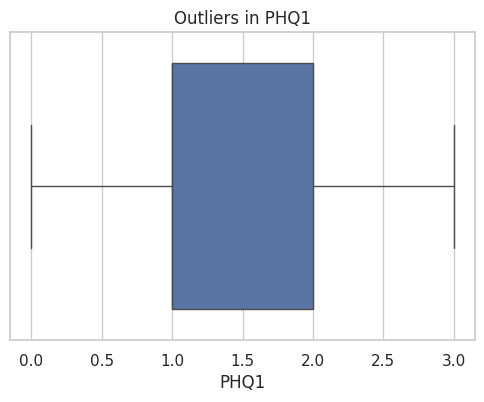

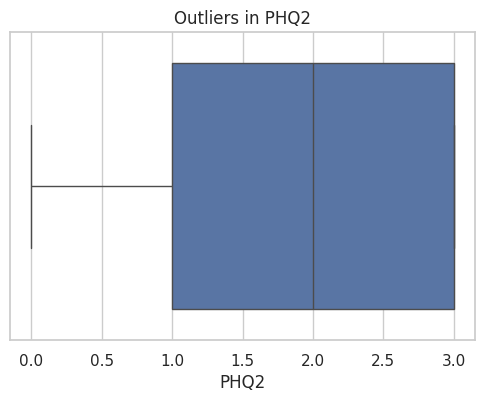

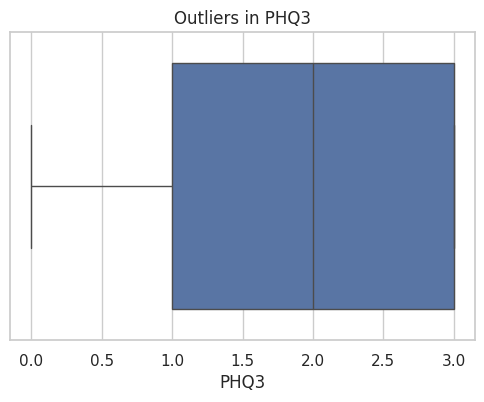

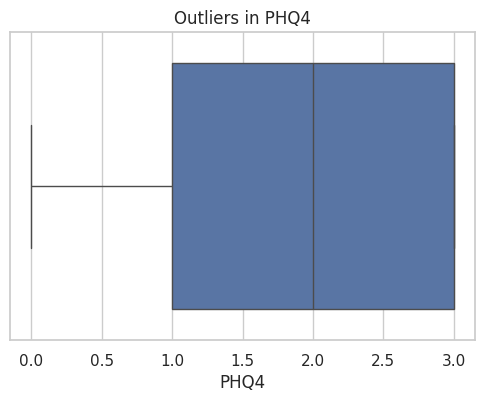

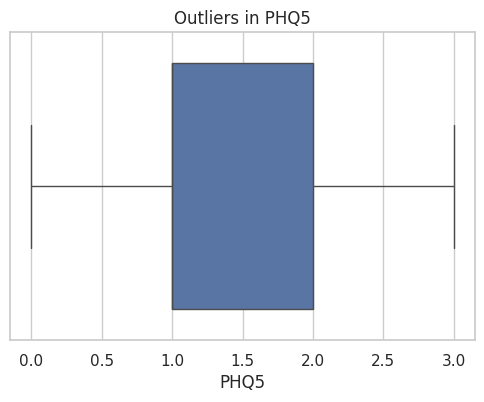

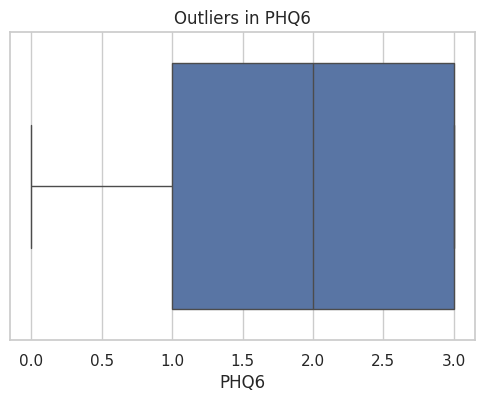

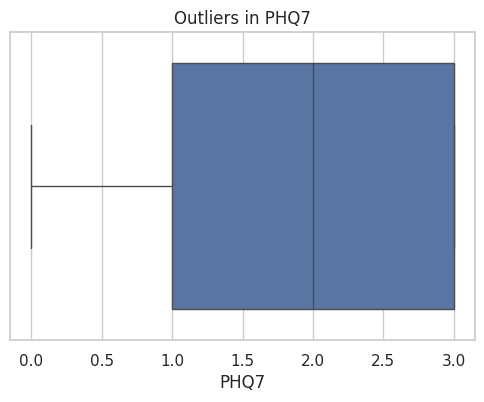

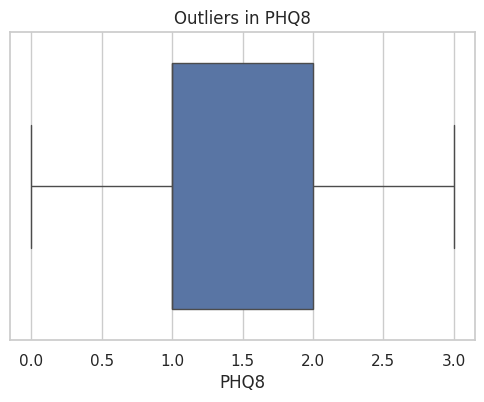

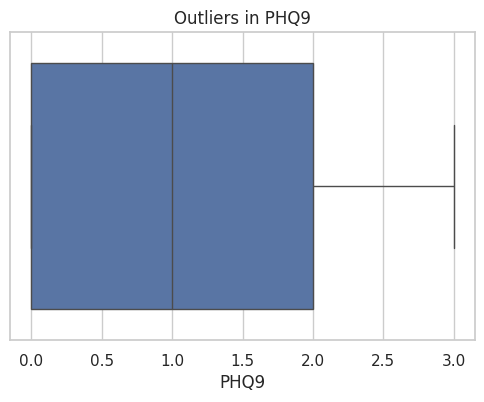

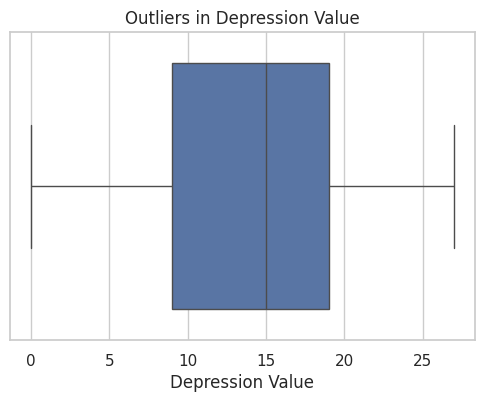

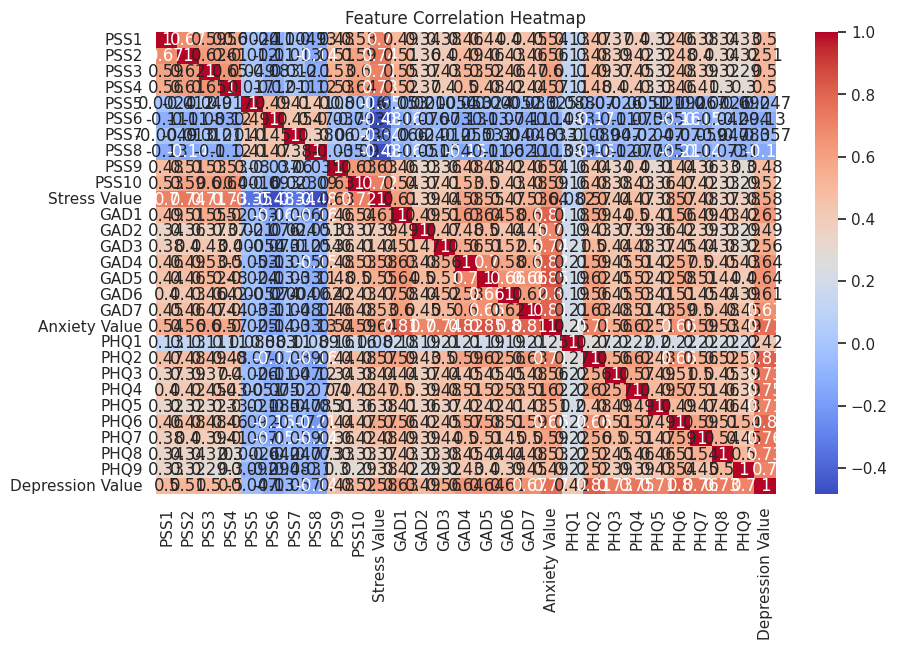

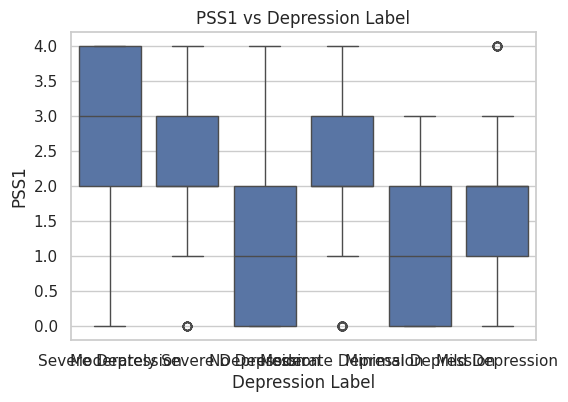

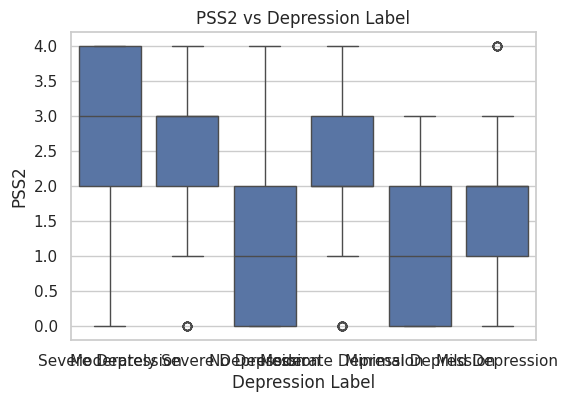

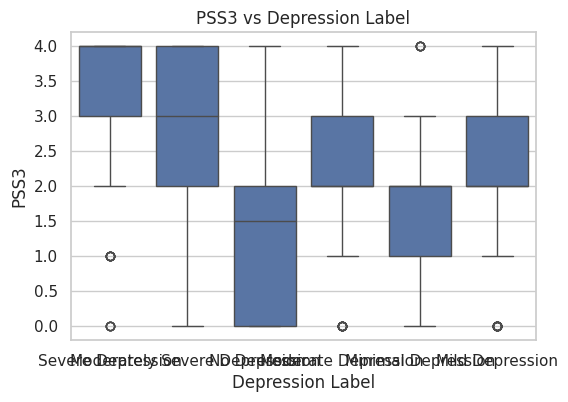

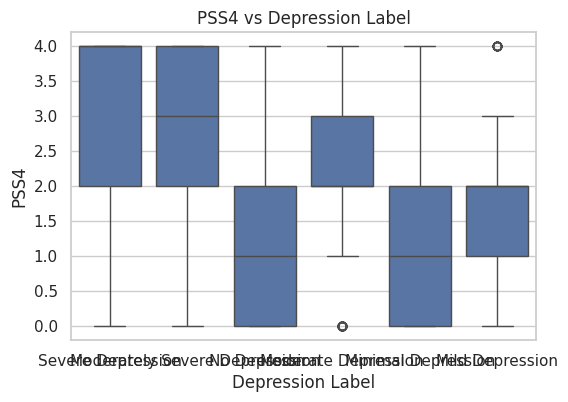

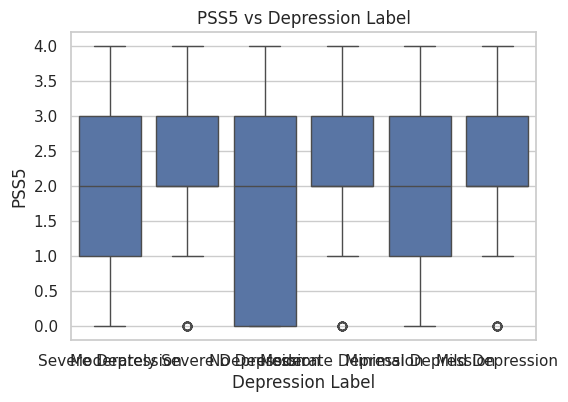

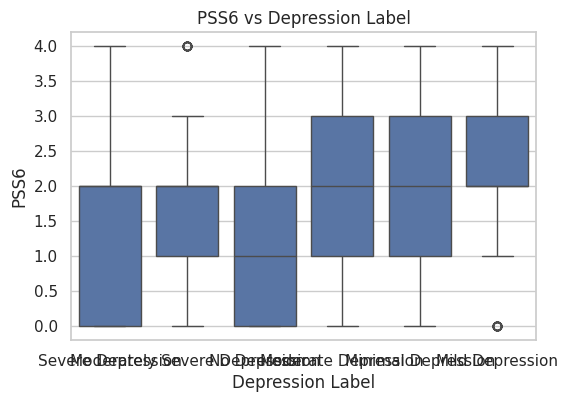

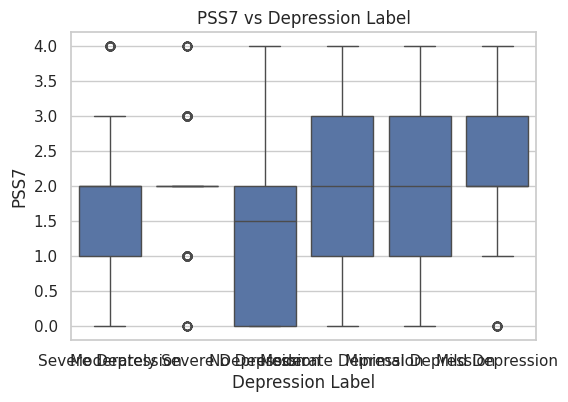

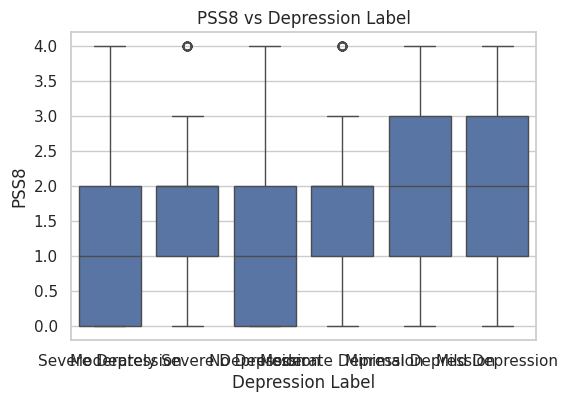

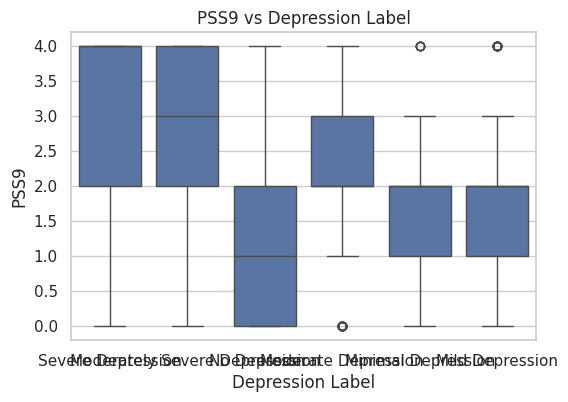

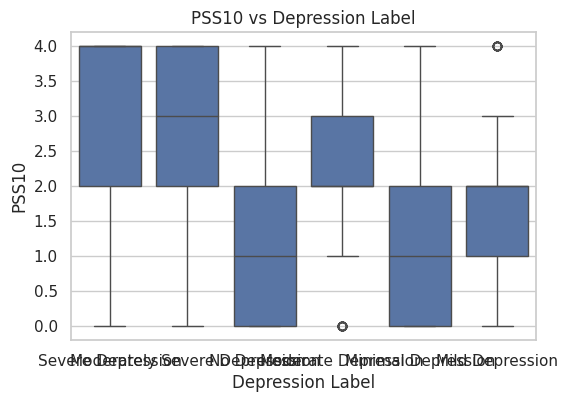

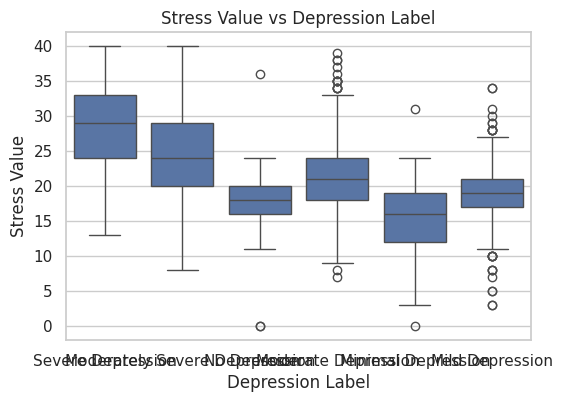

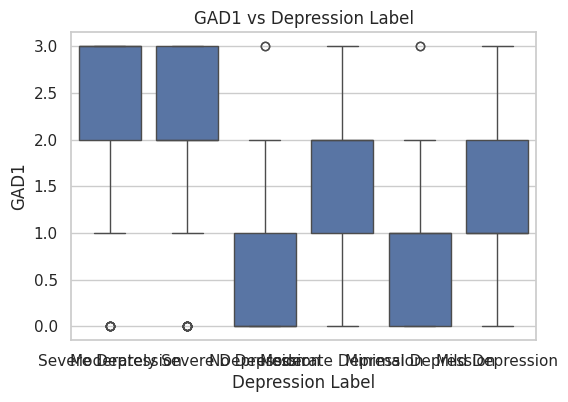

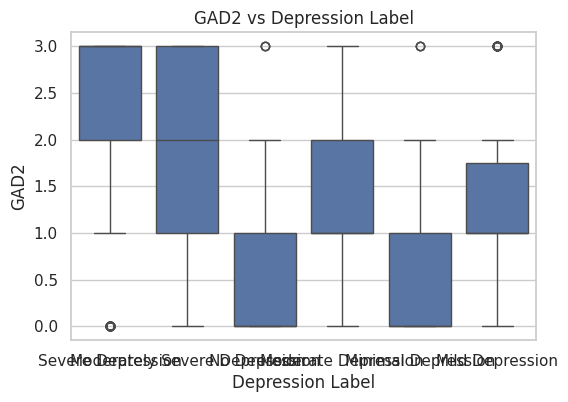

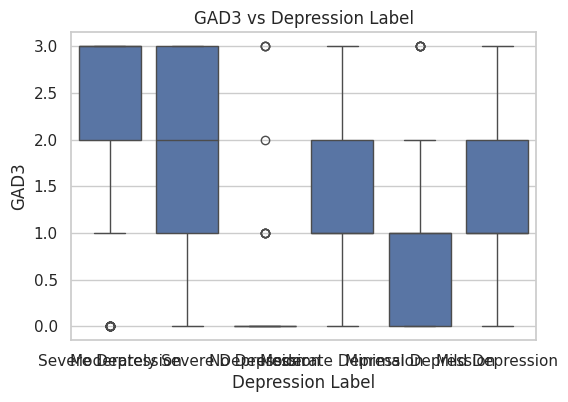

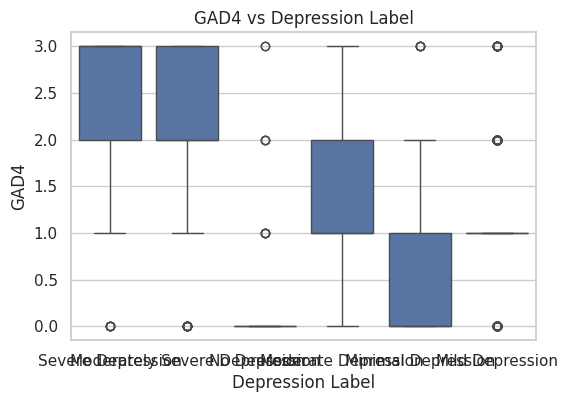

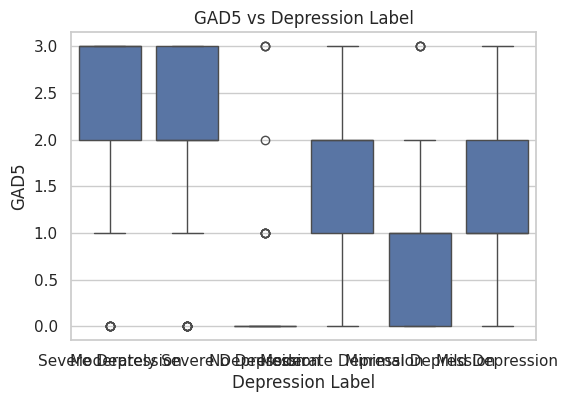

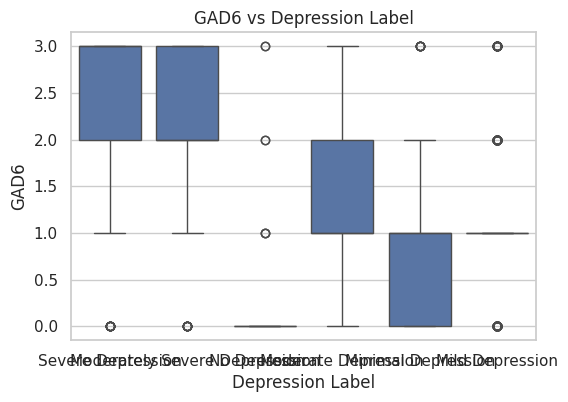

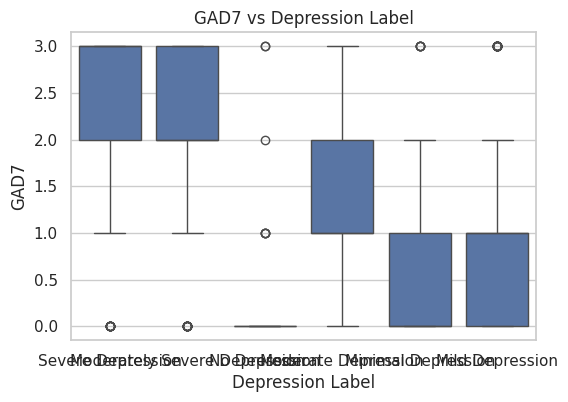

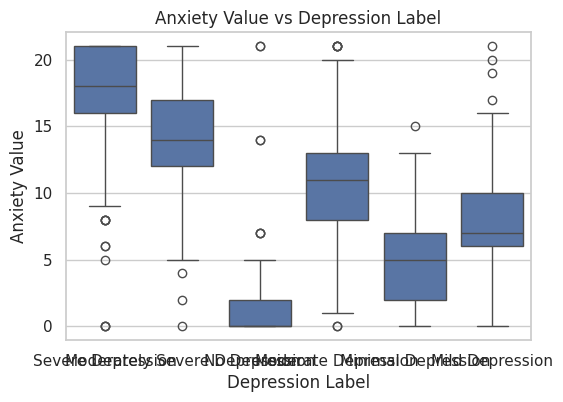

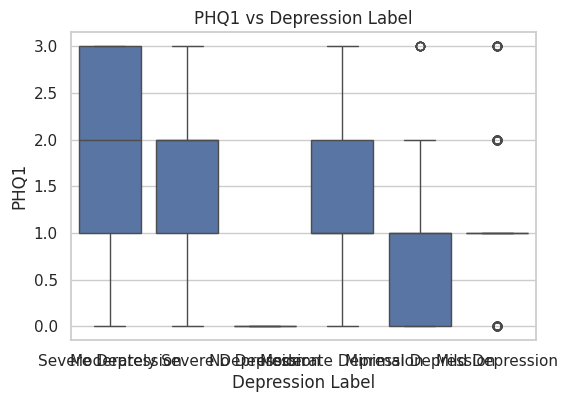

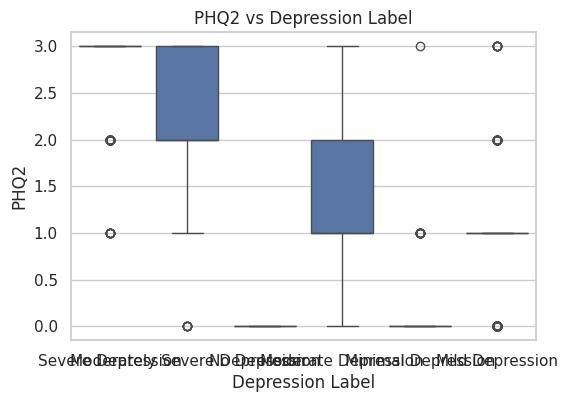

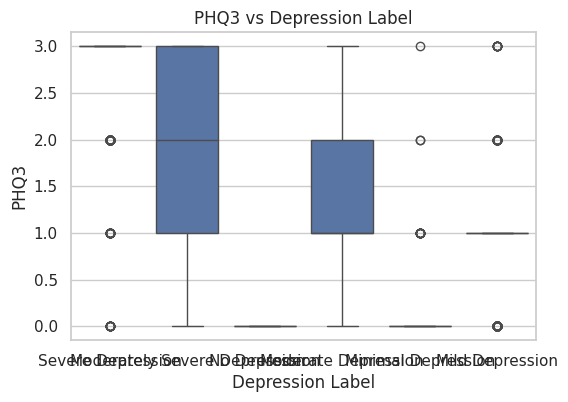

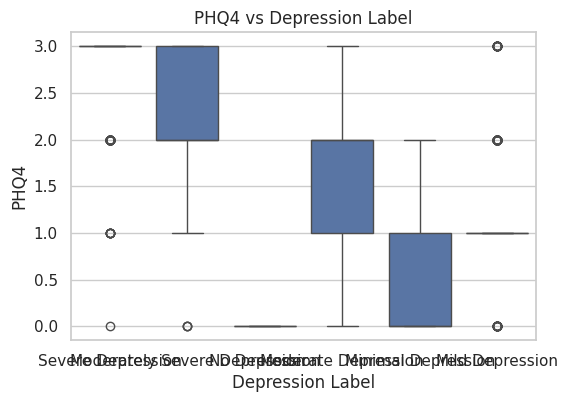

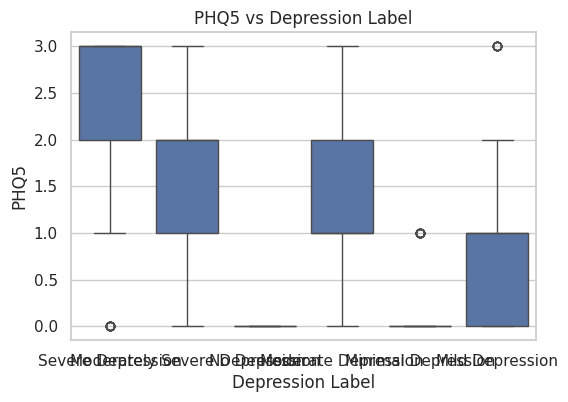

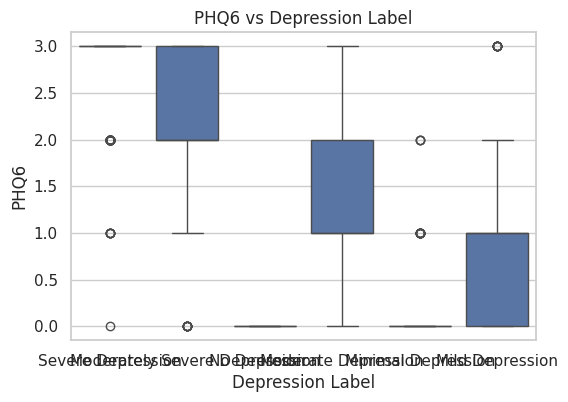

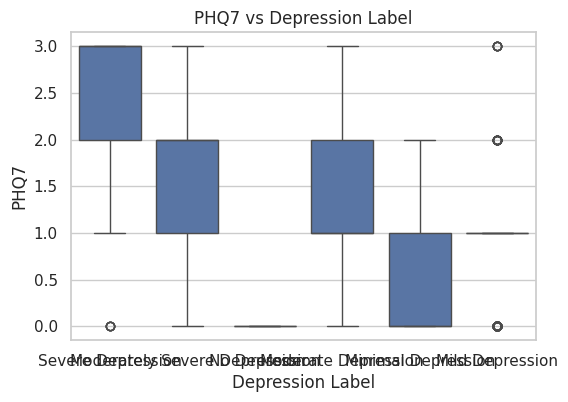

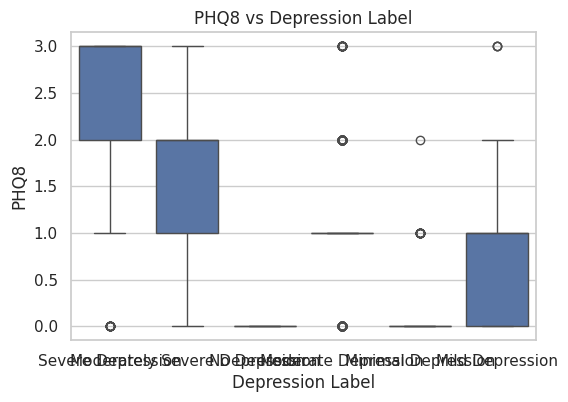

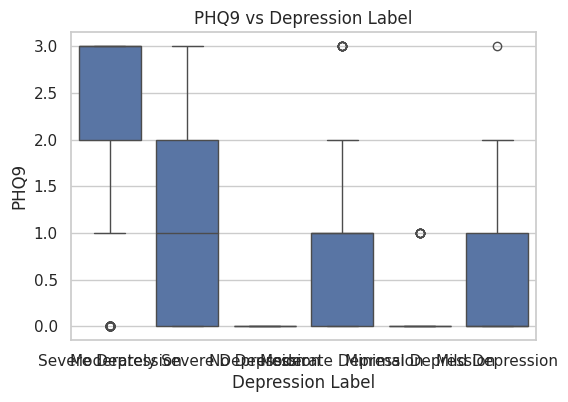

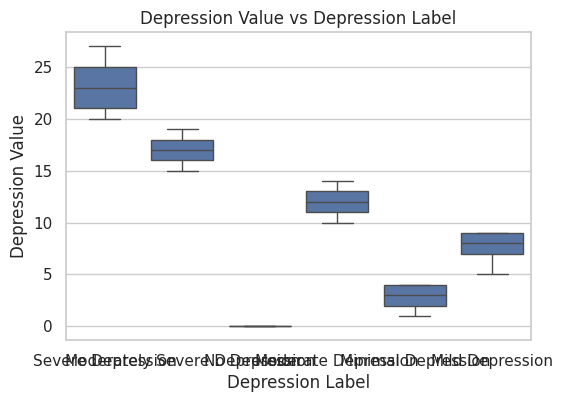


===== EDA COMPLETED SUCCESSFULLY =====


In [8]:
# ===============================
# 0. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ===============================
# 1. Load Data (if not loaded)
# ===============================
# df = pd.read_csv("data.csv")

print("\n===== DATA LOADED SUCCESSFULLY =====")

# ===============================
# 2. Basic Information
# ===============================
print("\n===== DATA INFO =====")
df.info()

print("\n===== FIRST 5 ROWS =====")
print(df.head())

print("\n===== LAST 5 ROWS =====")
print(df.tail())

# ===============================
# 3. Statistical Summary
# ===============================
print("\n===== STATISTICAL SUMMARY =====")
print(df.describe(include="all").T)

# ===============================
# 4. Column Types
# ===============================
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nNumeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

# ===============================
# 5. Missing Values Analysis
# ===============================
print("\n===== MISSING VALUES =====")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
}).sort_values(by="Missing Count", ascending=False)

print(missing_df)

# Heatmap of missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ===============================
# 6. Duplicate Check
# ===============================
print("\nDuplicate Rows:", df.duplicated().sum())

# ===============================
# 7. Skewness & Kurtosis
# ===============================
print("\n===== SKEWNESS =====")
print(df[numeric_cols].skew())

print("\n===== KURTOSIS =====")
print(df[numeric_cols].kurt())

# ===============================
# 8. Target Variable Analysis
# ===============================
target_col = "Depression Label"   # CHANGE THIS ACCORDING TO YOUR DATA

print("\n===== TARGET DISTRIBUTION =====")
print(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Target Variable Distribution")
plt.show()

# Percentage of target classes
print("\n===== TARGET PERCENTAGE =====")
print(df[target_col].value_counts(normalize=True) * 100)

# ===============================
# 9. Categorical Feature Analysis
# ===============================
for col in categorical_cols:
    if col != target_col:
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, data=df)
        plt.title(f"{col} Distribution")
        plt.xticks(rotation=45)
        plt.show()

# ===============================
# 10. Numerical Feature Distribution
# ===============================
df[numeric_cols].hist(figsize=(12,10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

# KDE plots (optional better visualization)
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# ===============================
# 11. Outlier Detection (Boxplot)
# ===============================
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

# ===============================
# 12. Correlation Matrix
# ===============================
plt.figure(figsize=(10,6))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ===============================
# 13. Feature vs Target Analysis
# ===============================
for col in numeric_cols:
    if col != target_col:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[target_col], y=df[col])
        plt.title(f"{col} vs {target_col}")
        plt.show()

# ===============================
# 14. Pairplot (Optional - small dataset only)
# ===============================
# sns.pairplot(df[numeric_cols + [target_col]])
# plt.show()

# ===============================
# END OF EDA
# ===============================
print("\n===== EDA COMPLETED SUCCESSFULLY =====")

# Categorical Feature Analysis

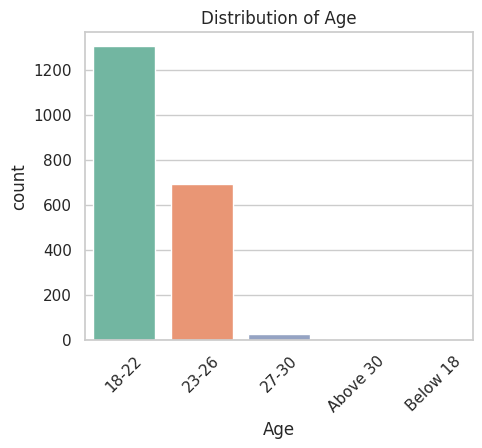

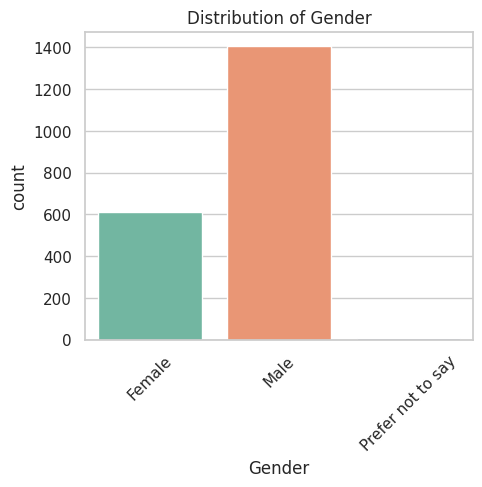

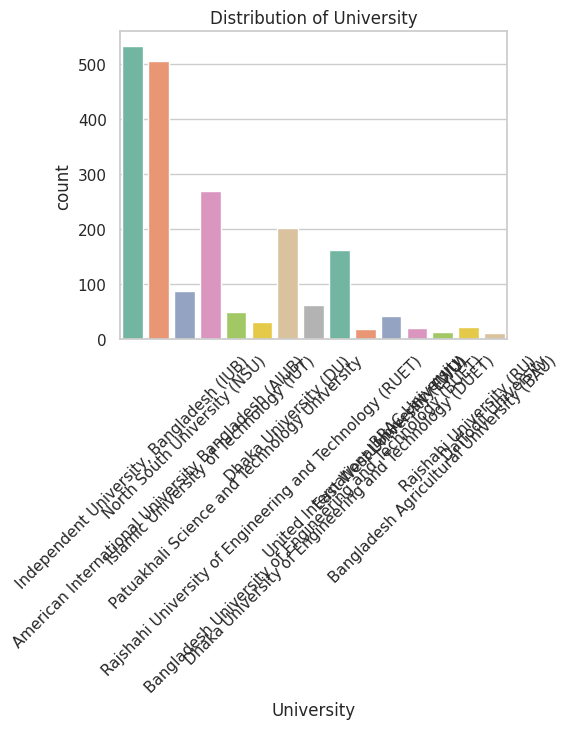

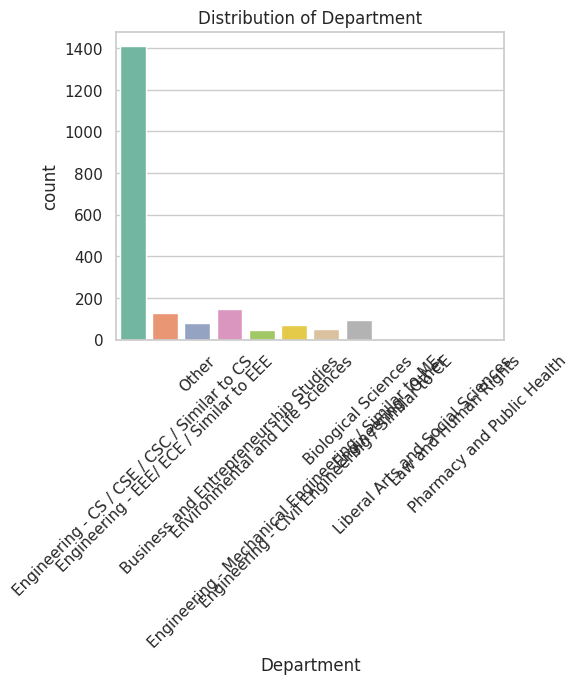

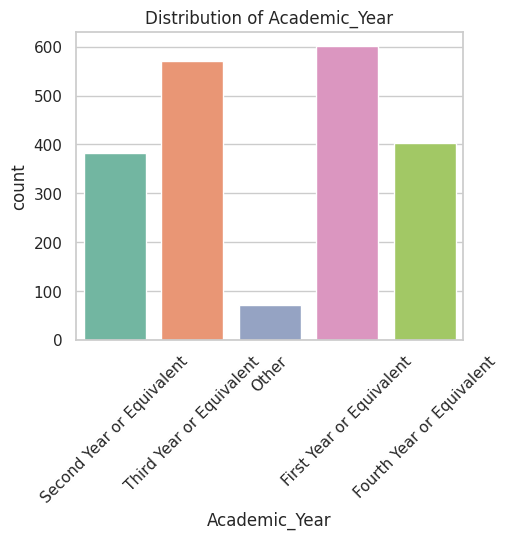

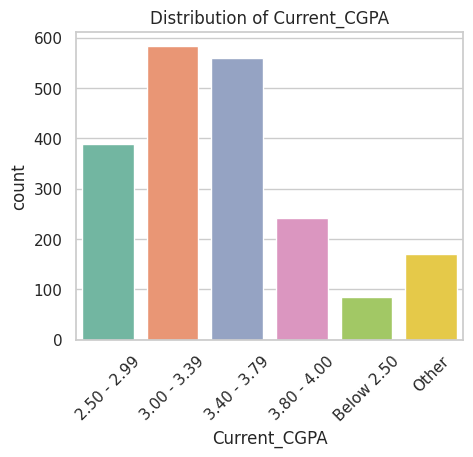

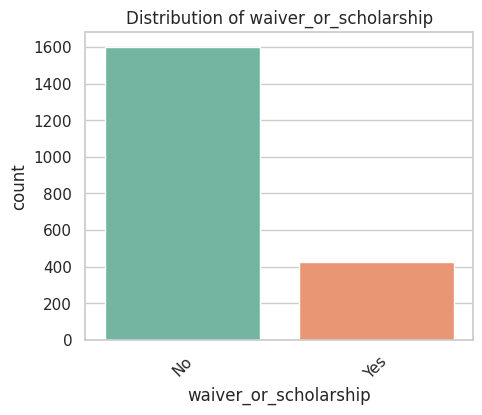

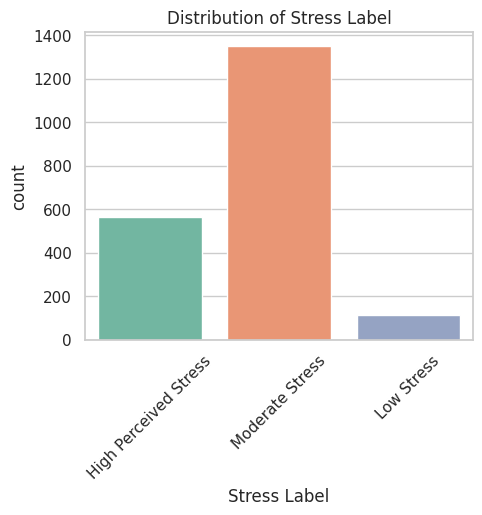

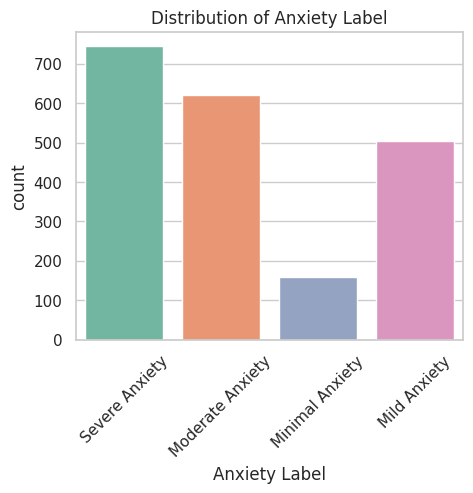

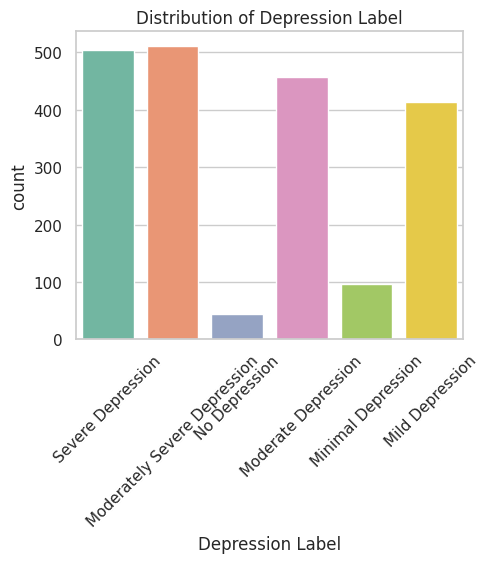

In [9]:
for col in categorical_cols:
    plt.figure(figsize=(5,4) )
    sns.countplot(x=col, data=df, palette="Set2")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

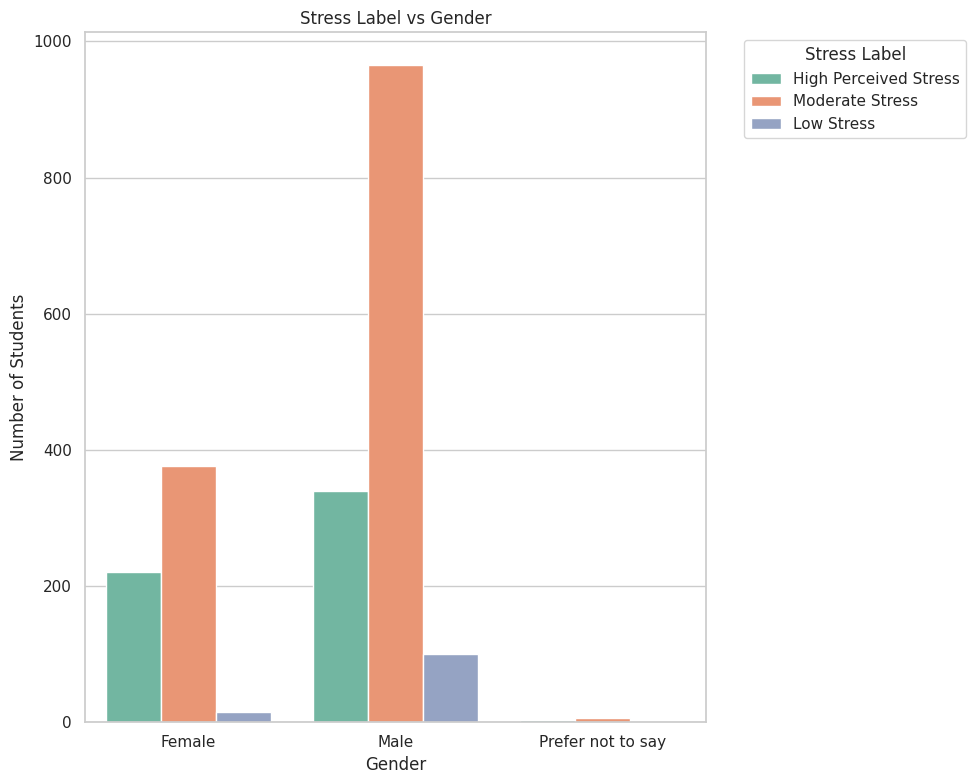

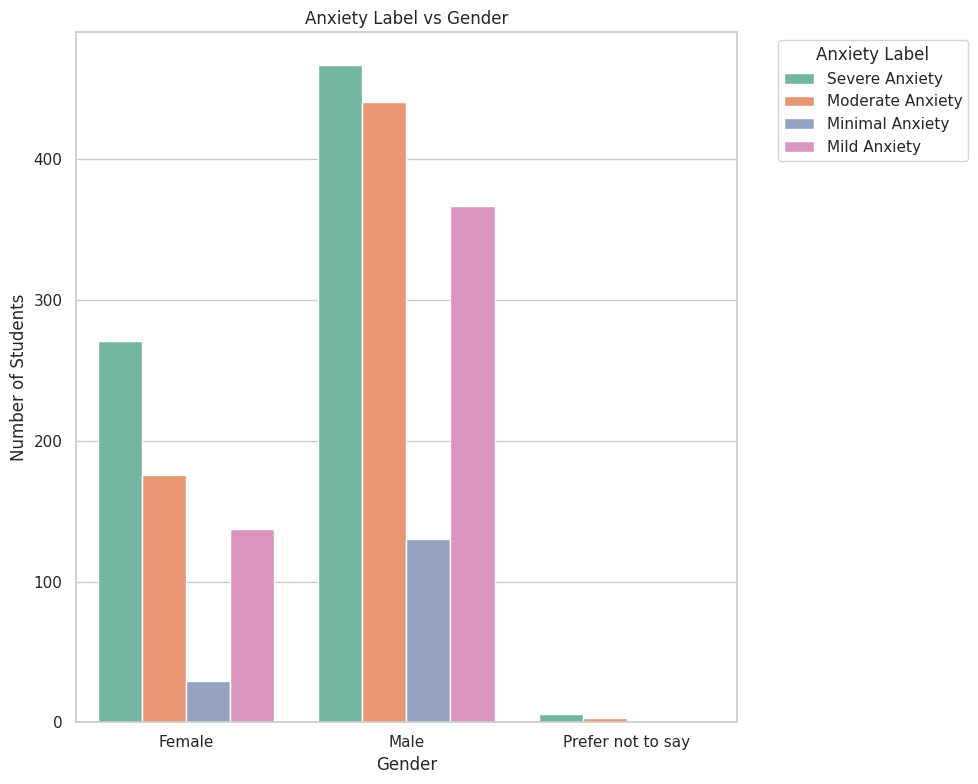

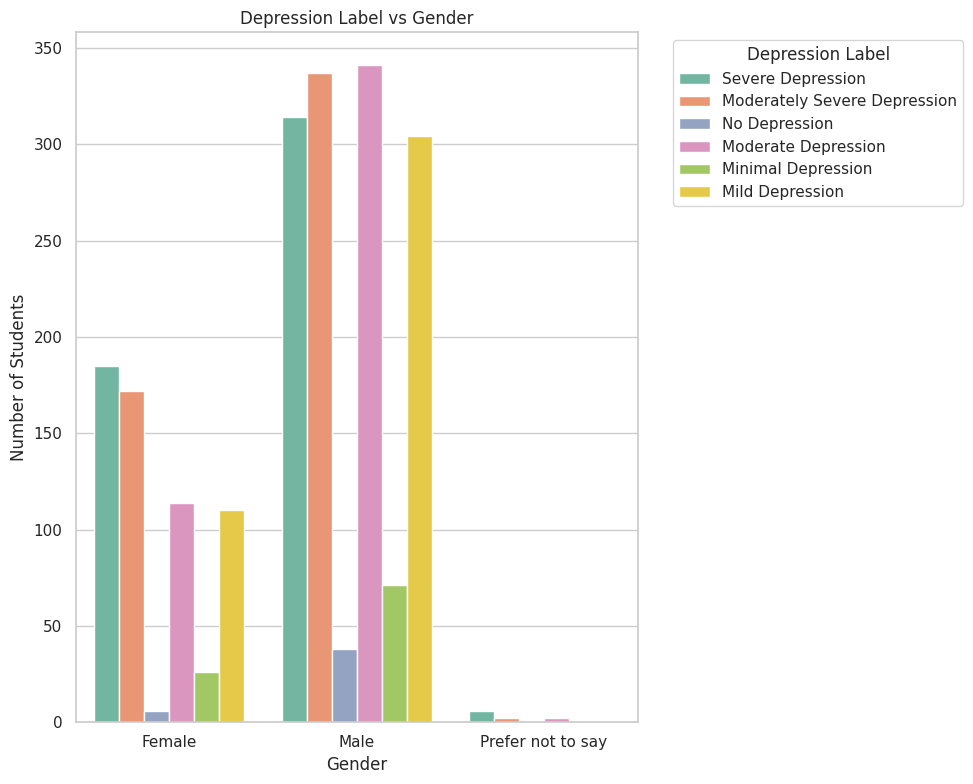

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

gender_col = 'Gender'
targets = ['Stress Label', 'Anxiety Label', 'Depression Label']

for target in targets:
    plt.figure(figsize=(10,8))

    # Count plot for Gender vs target label
    sns.countplot(x=gender_col, hue=target, data=df, palette="Set2")

    plt.title(f"{target} vs {gender_col}")
    plt.xlabel("Gender")
    plt.ylabel("Number of Students")
    plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


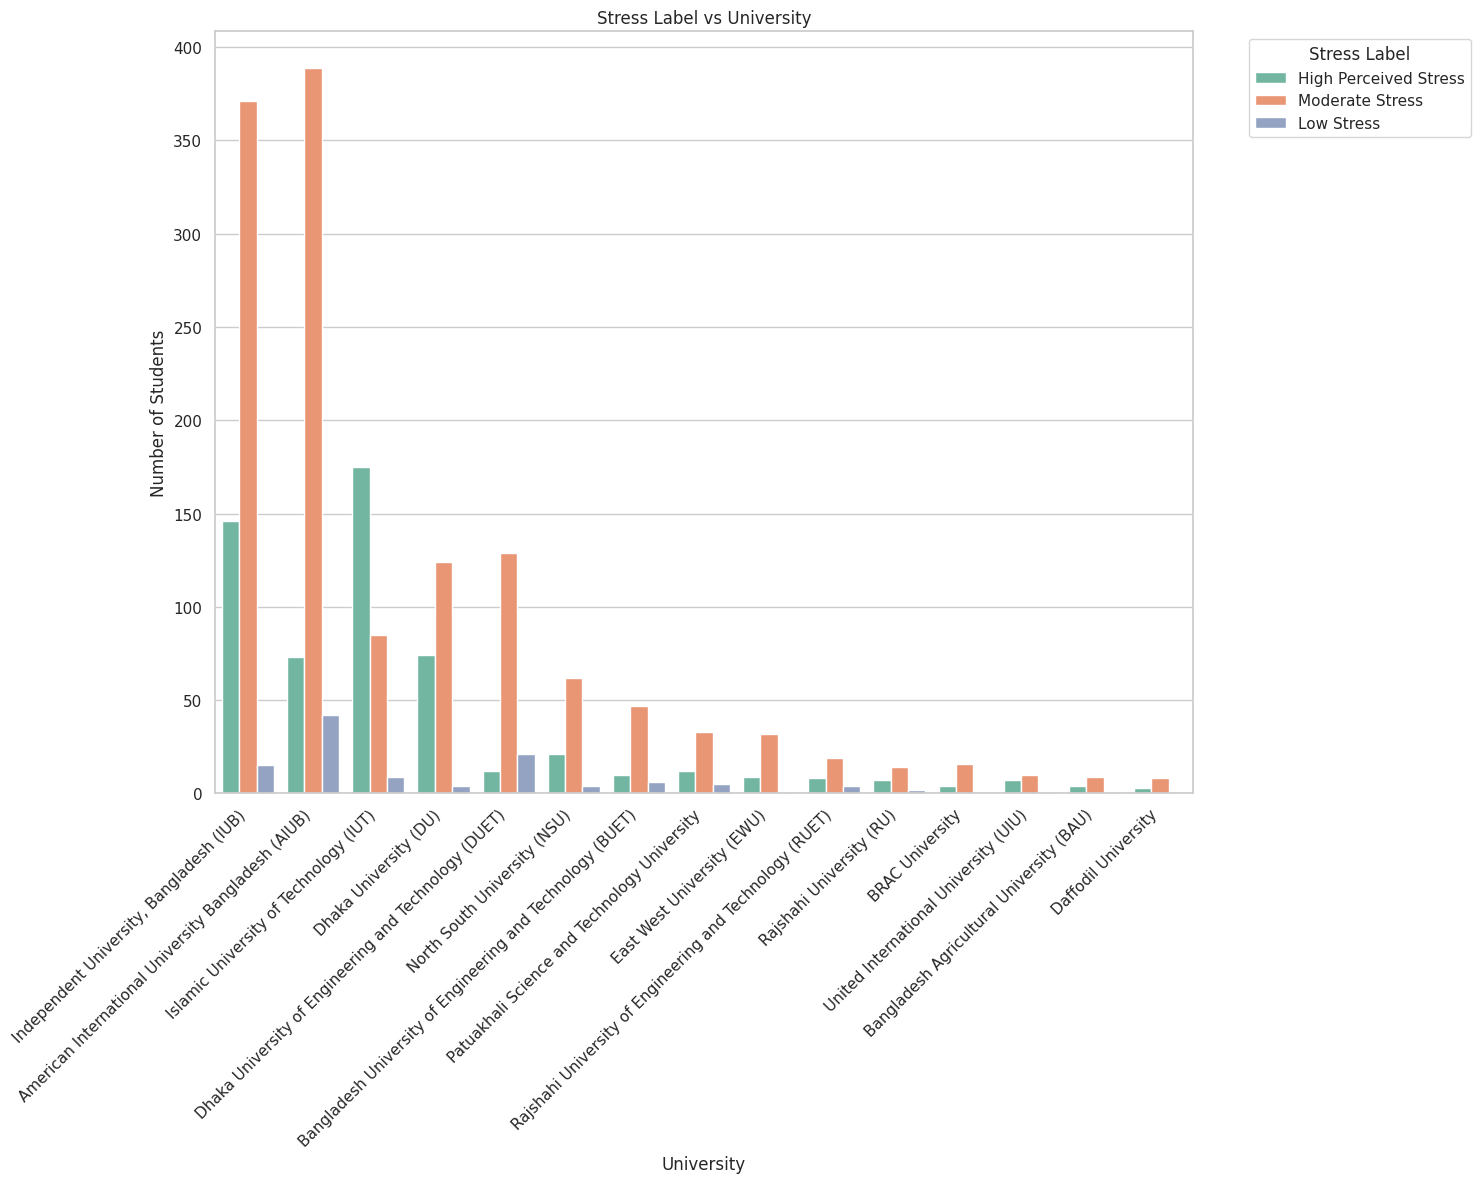

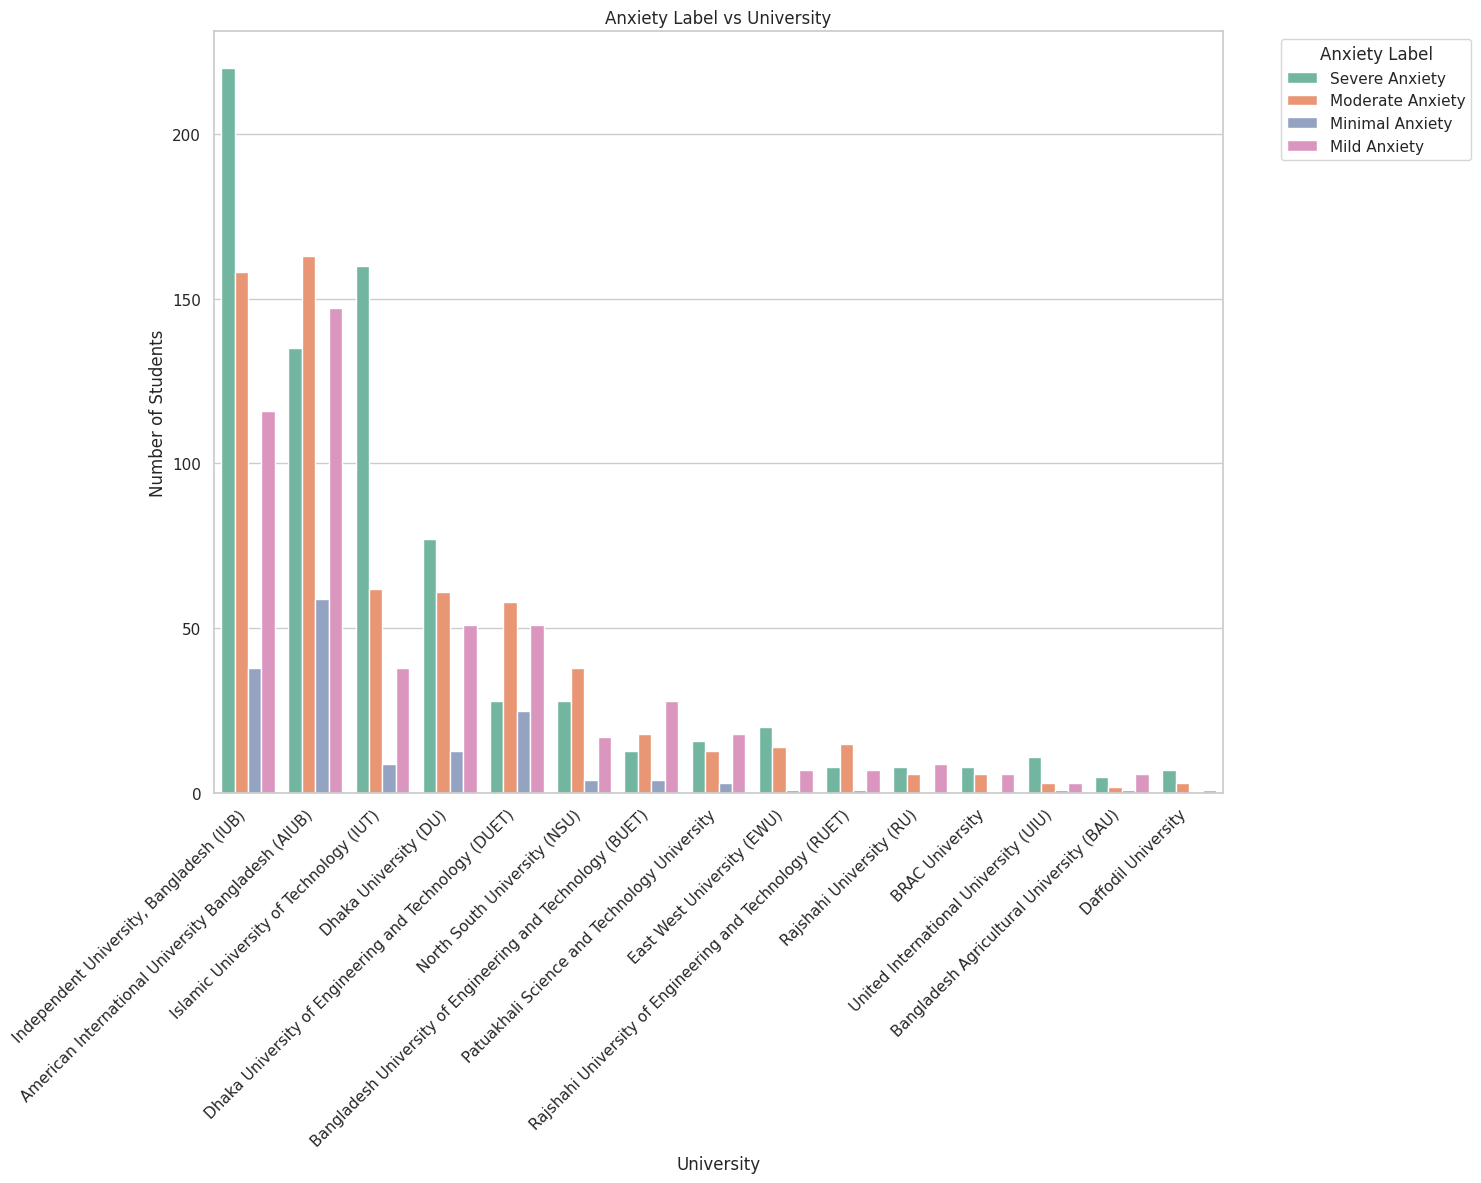

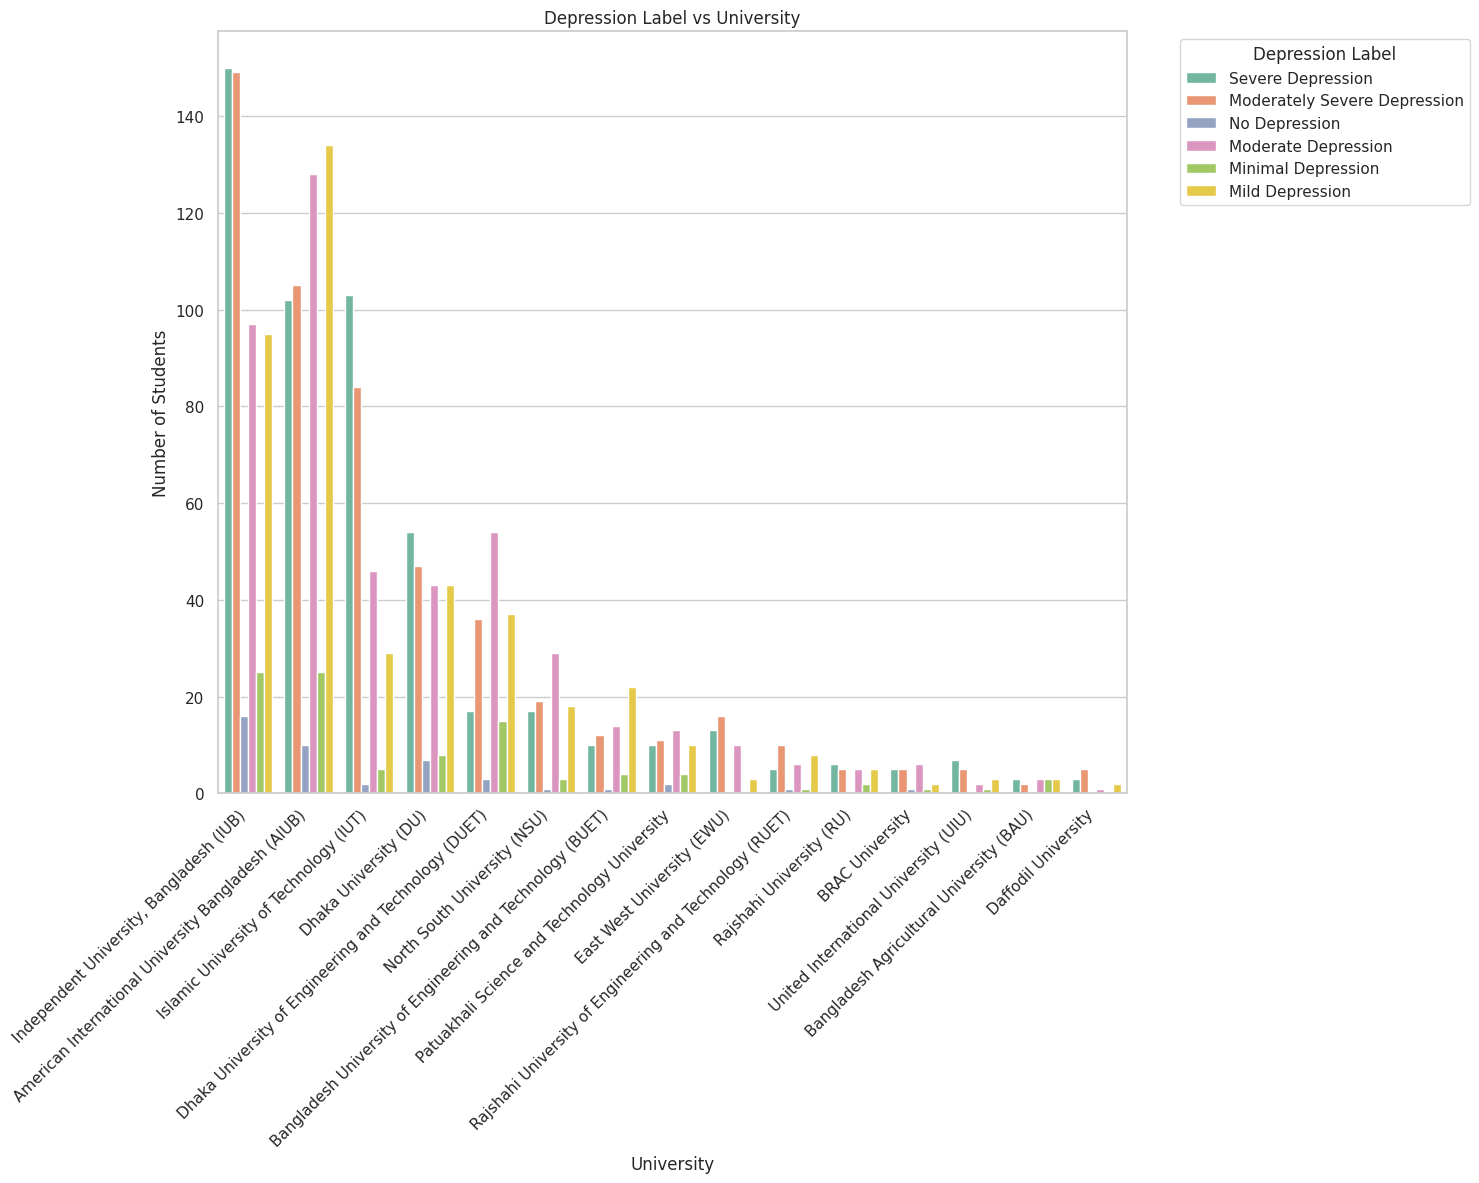

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

uni_col = 'University'
targets = ['Stress Label', 'Anxiety Label', 'Depression Label']

# Optional: sort universities by number of students
uni_order = df[uni_col].value_counts().index

for target in targets:
    plt.figure(figsize=(15,12))

    # Count plot
    sns.countplot(x=uni_col, hue=target, data=df, palette="Set2", order=uni_order)

    plt.title(f"{target} vs {uni_col}")
    plt.xlabel("University")
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


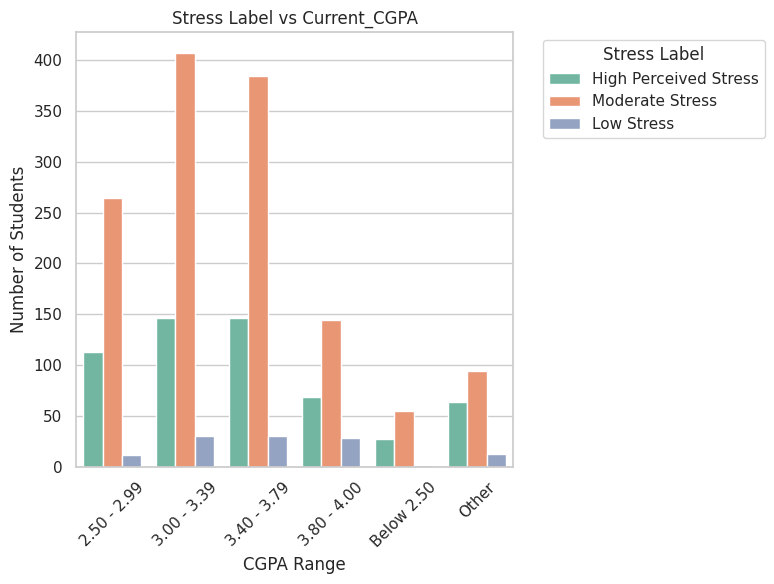

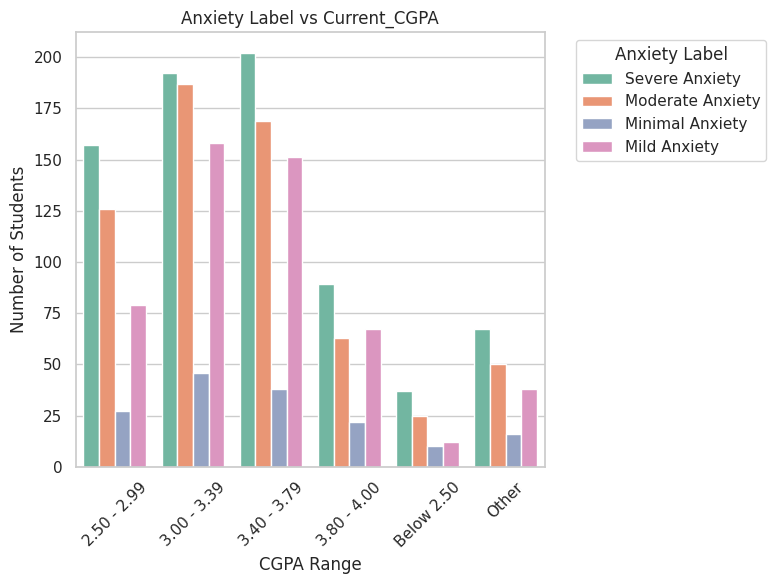

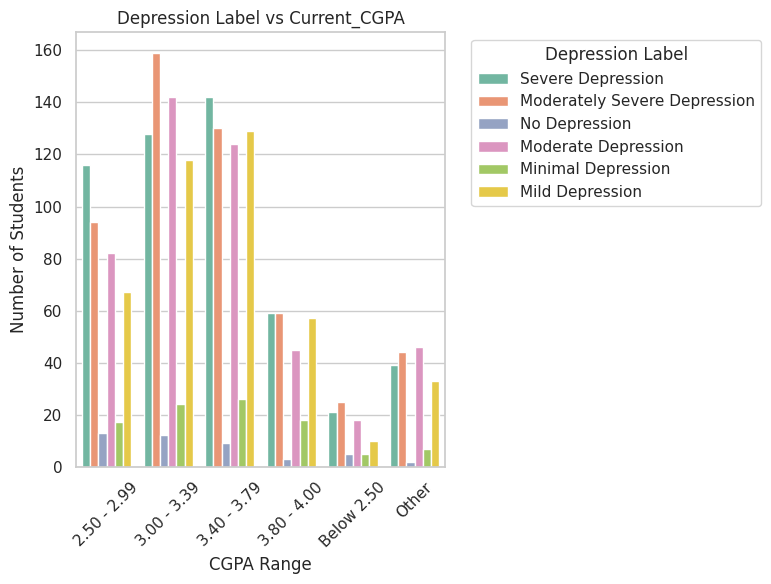

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()  # remove spaces from column names
cgpa_col = 'Current_CGPA'
targets = ['Stress Label', 'Anxiety Label', 'Depression Label']

for target in targets:
    plt.figure(figsize=(8,6))
    sns.countplot(x=cgpa_col, hue=target, data=df, palette="Set2")
    plt.title(f"{target} vs {cgpa_col}")
    plt.xlabel("CGPA Range")
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45)
    plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Distribution Plot

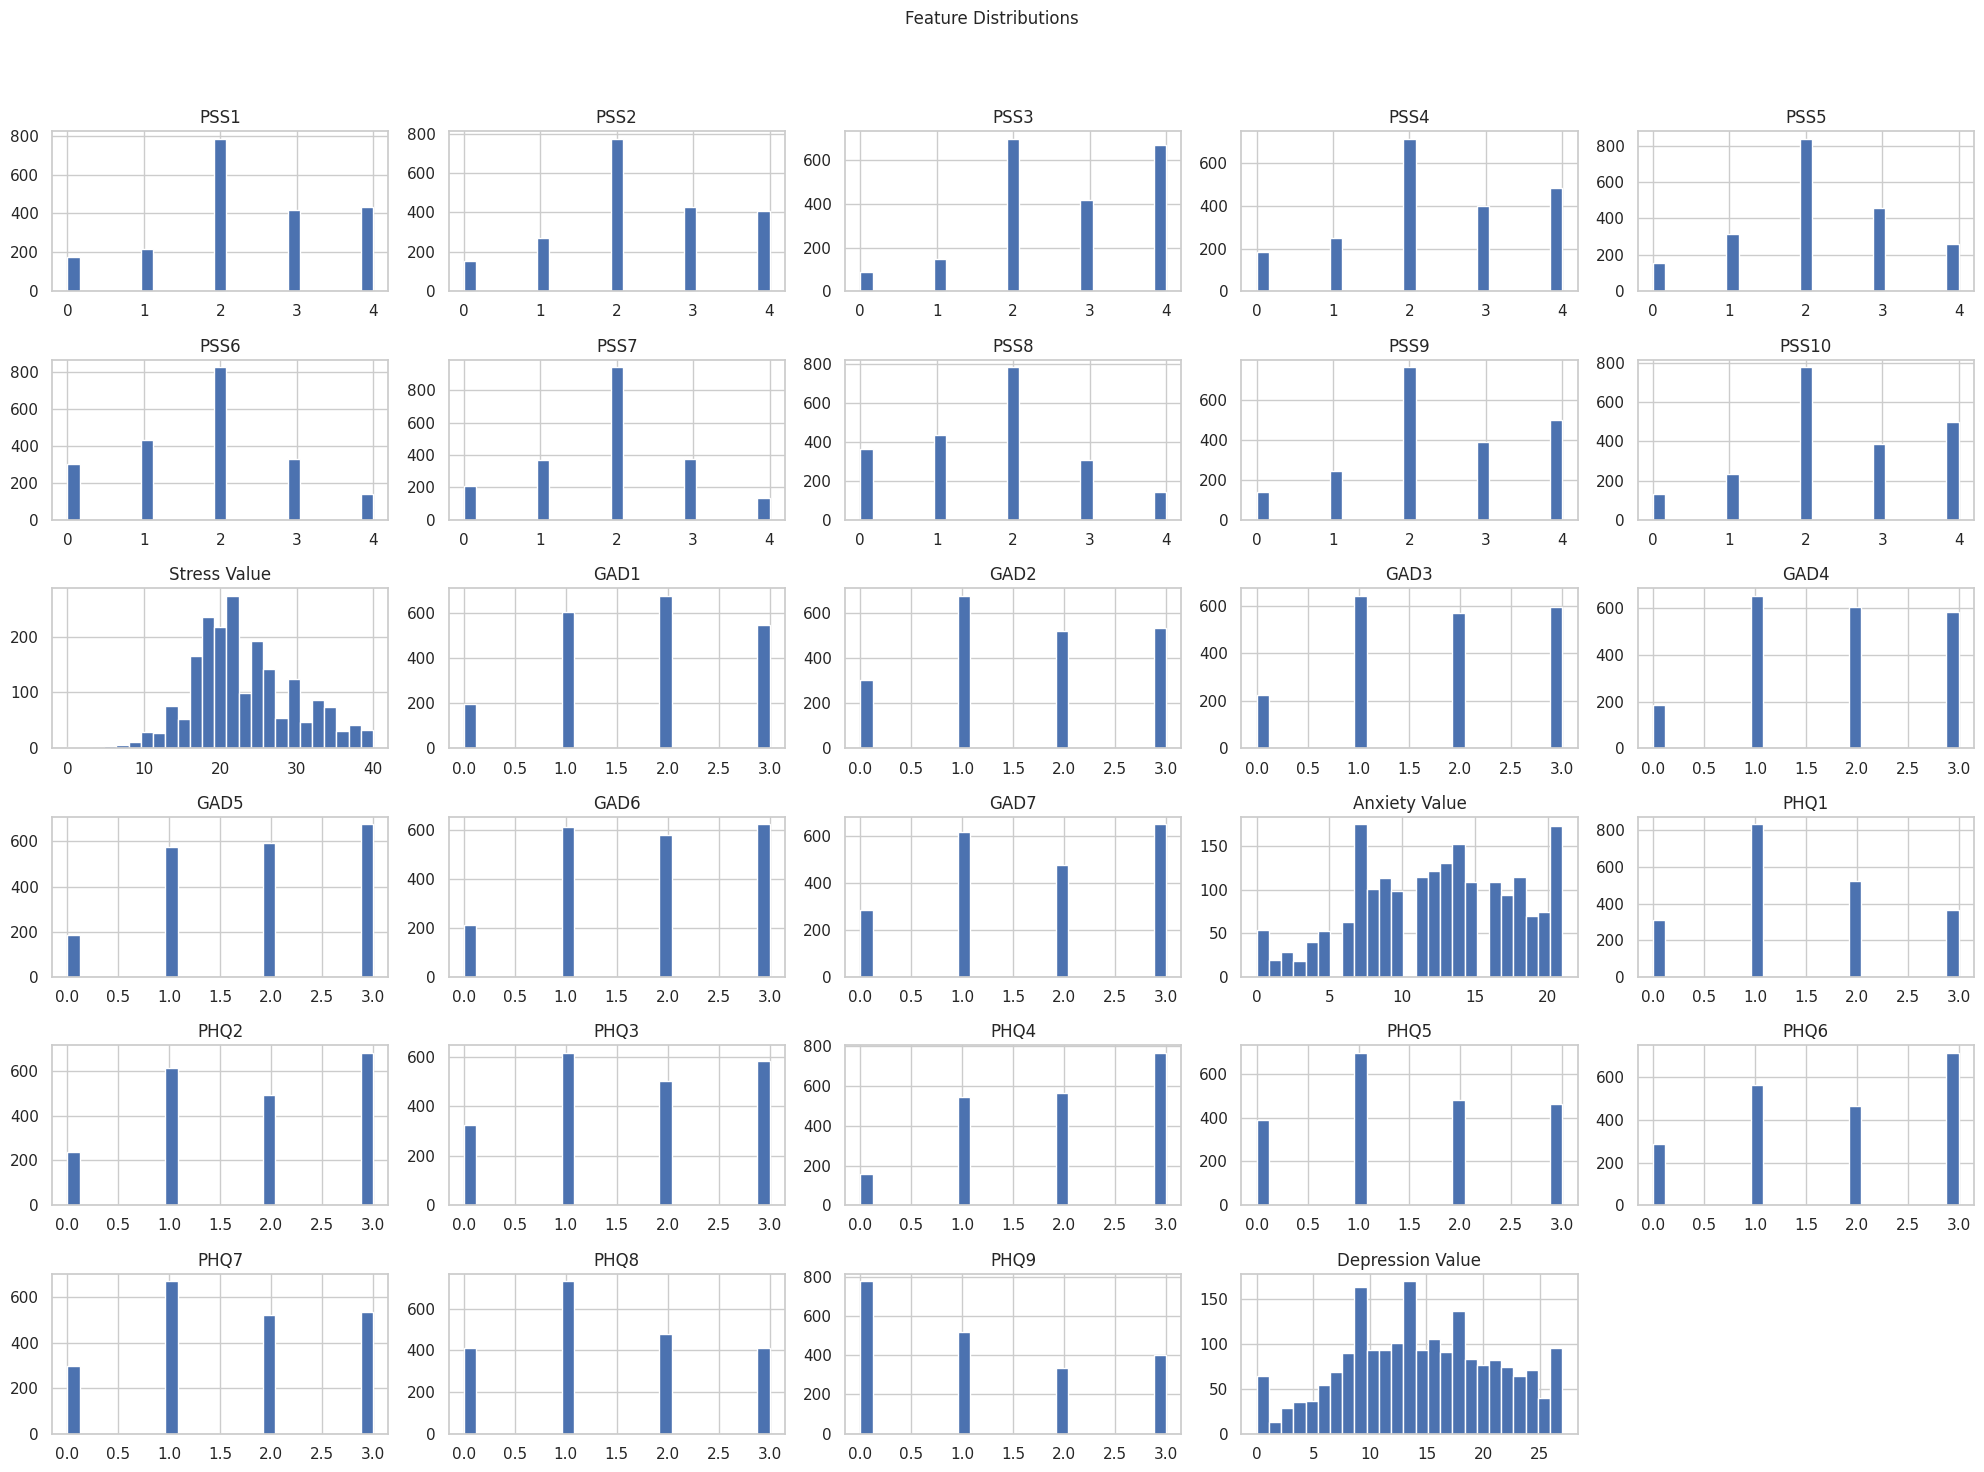

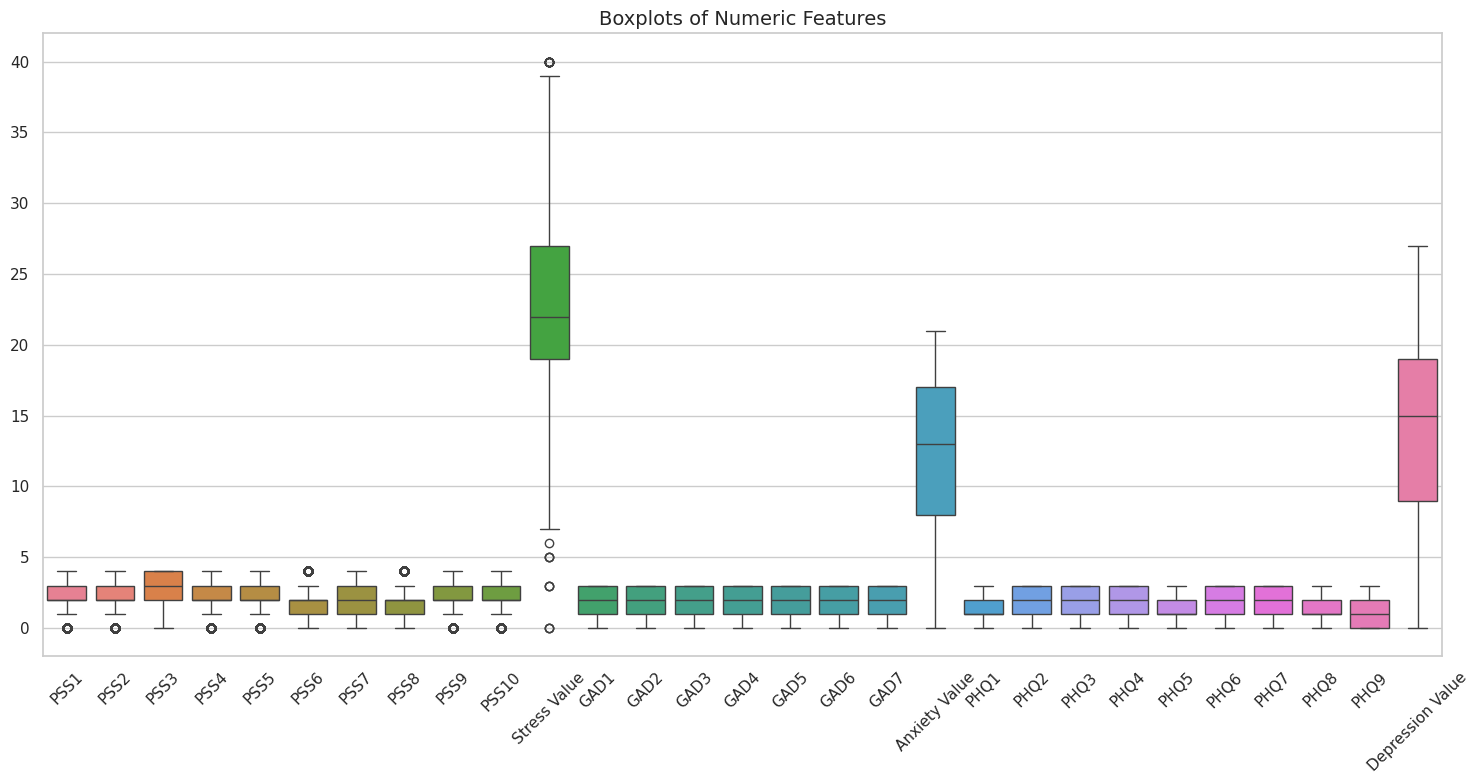

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numeric features
df[numeric_cols].hist(bins=25, figsize=(20, 15))
plt.suptitle("Feature Distributions", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # keeps spacing neat
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots of Numeric Features", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation and Heatmap

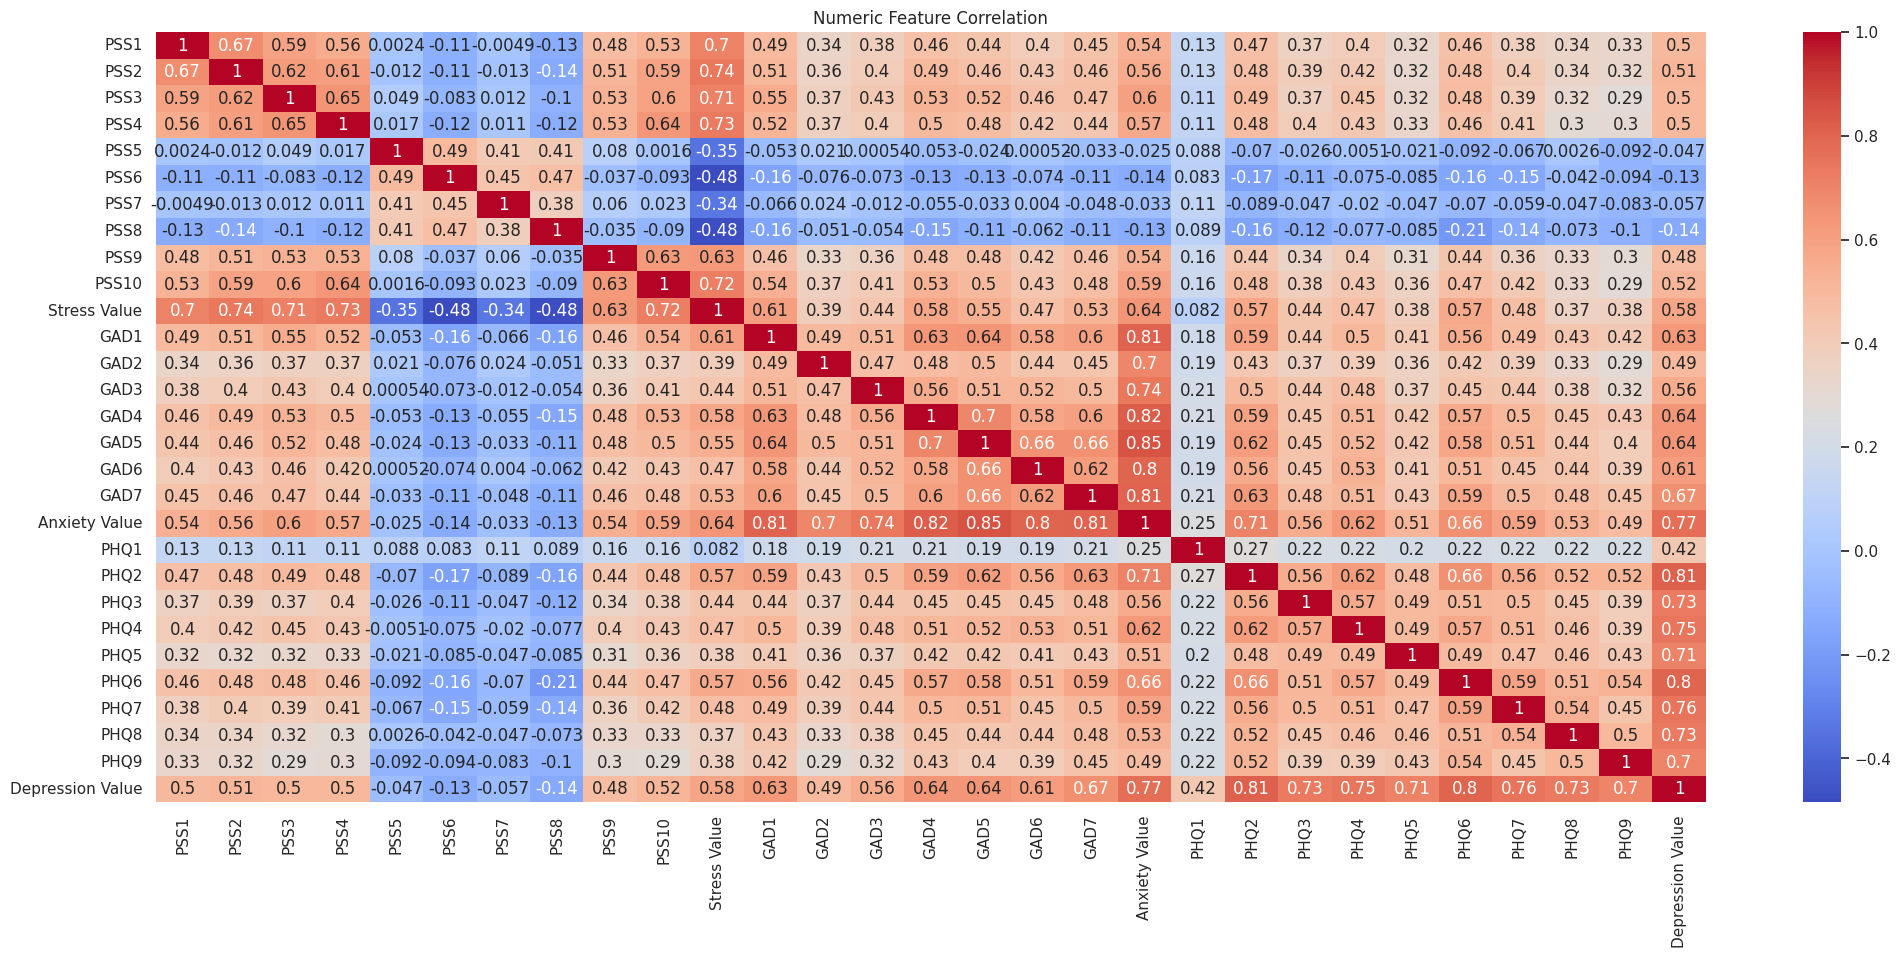

In [14]:
# Define numeric columns for the whole df
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Plot correlation heatmap
plt.figure(figsize=(25,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Numeric Feature Correlation")
plt.show()

# Heatmap

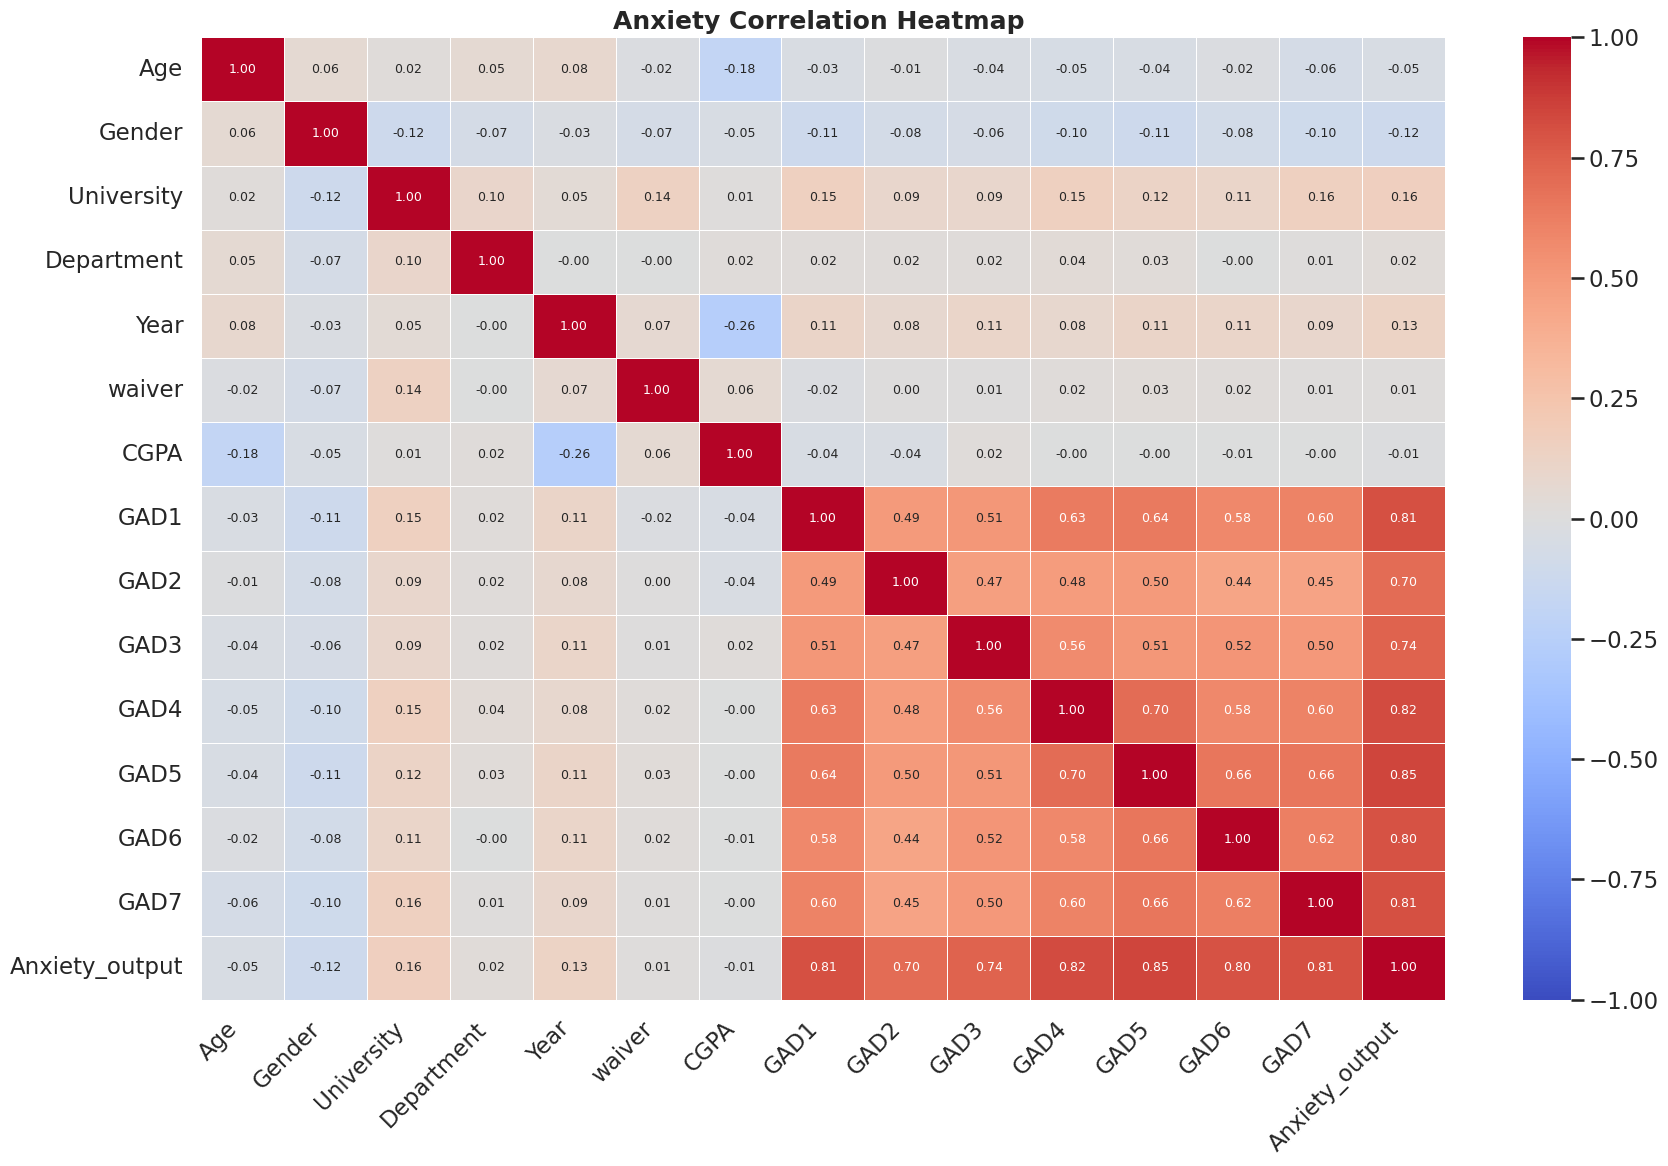

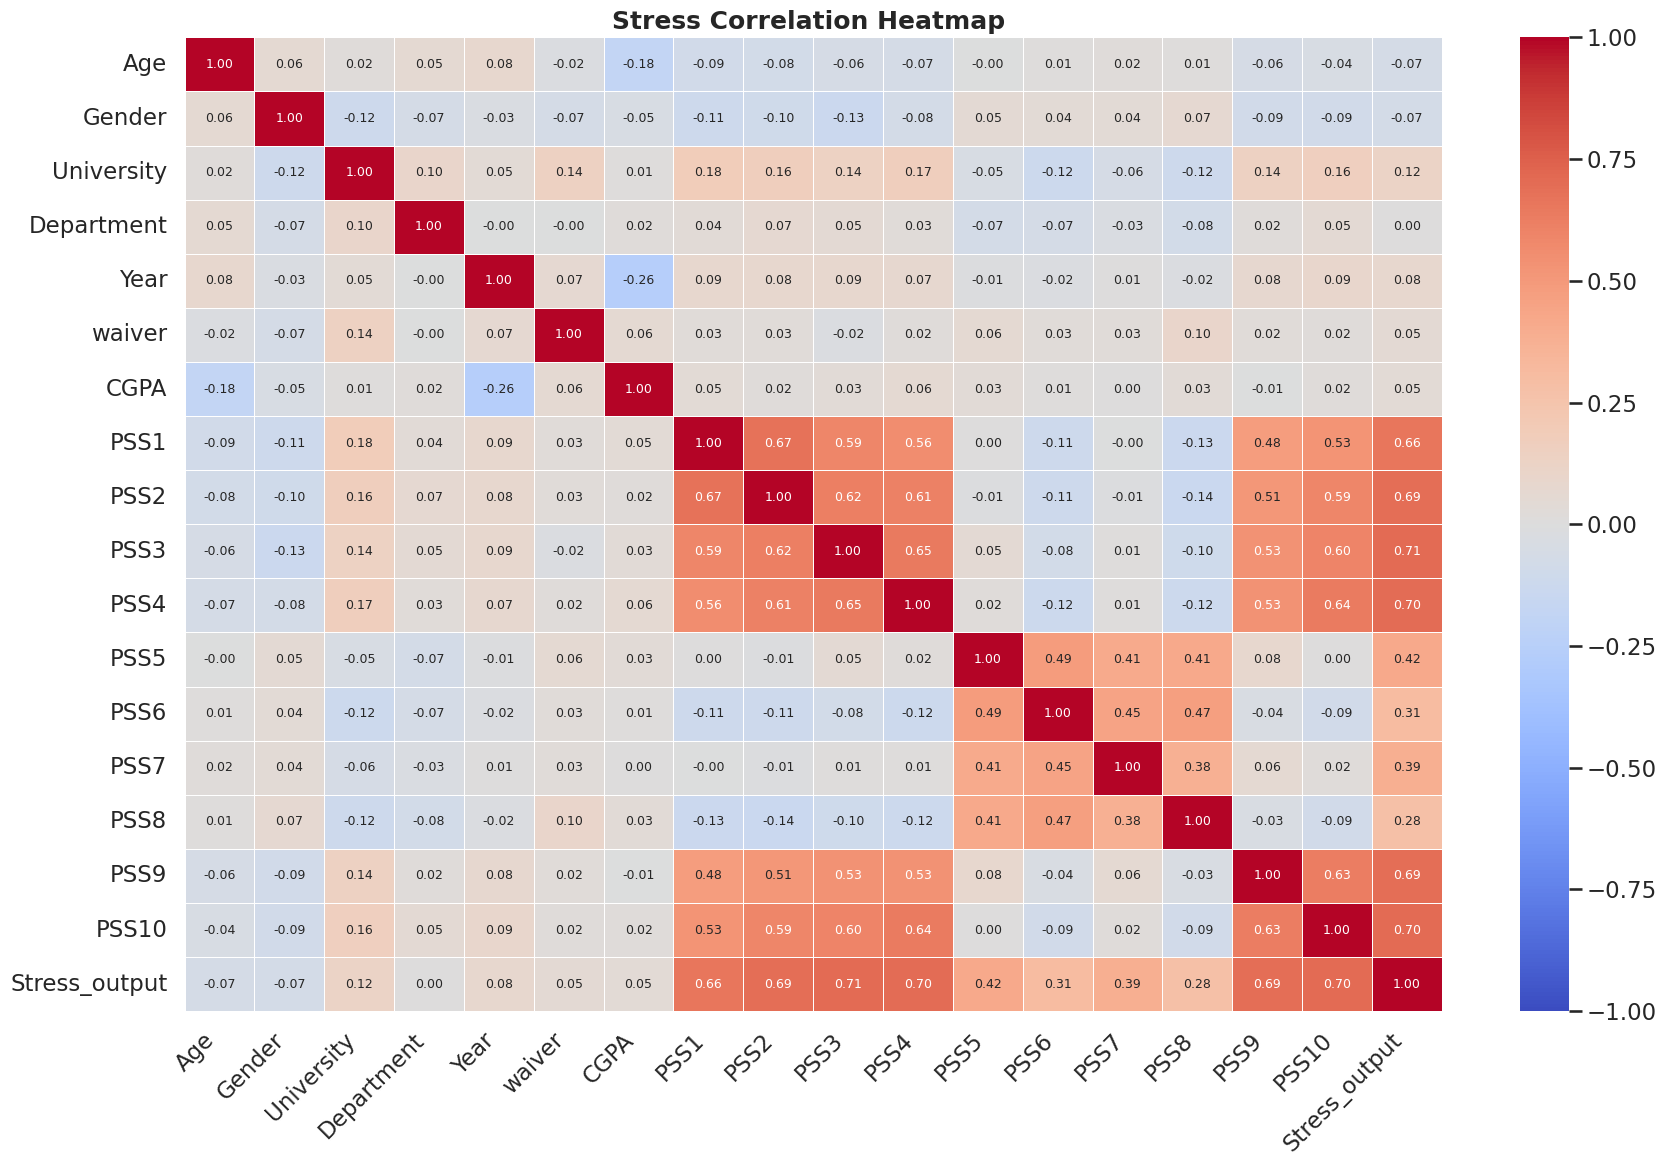

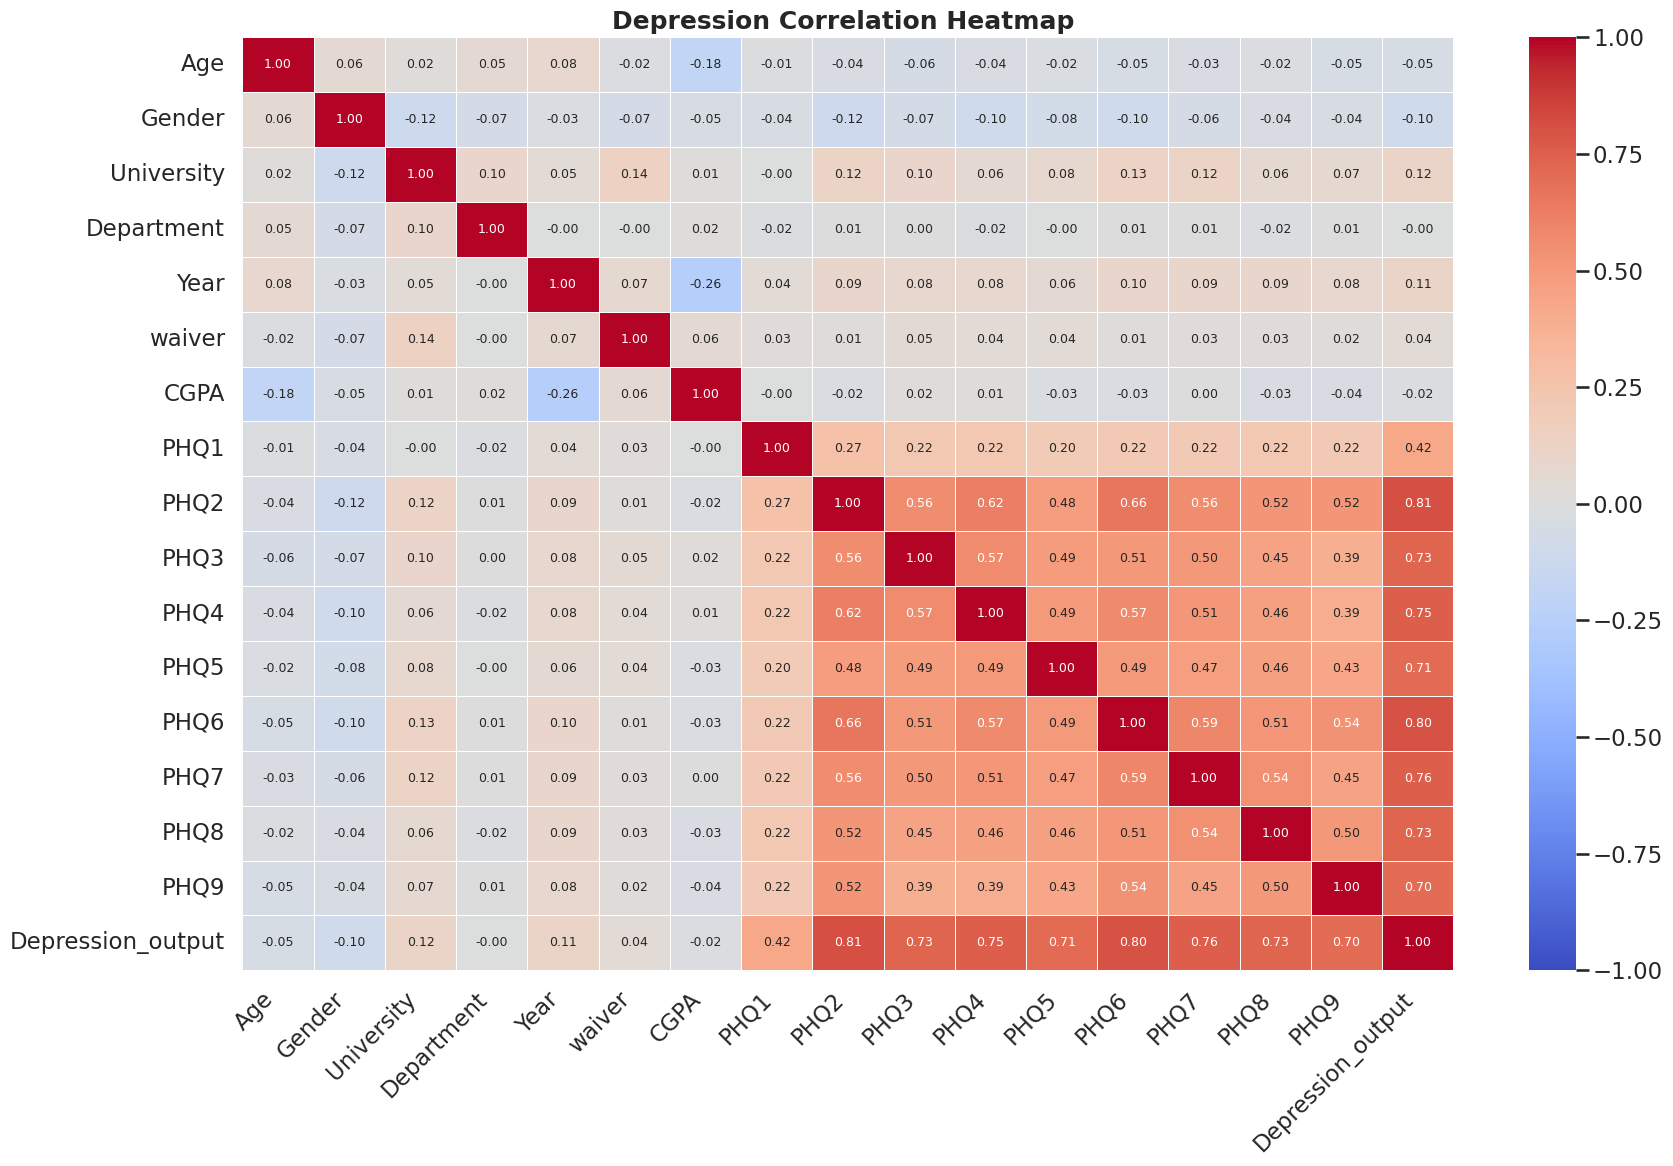

   Anxiety_output  Stress_output  Depression_output
0        2.142857            2.7           2.222222
1        1.714286            2.6           2.111111
2        0.000000            0.1           0.000000
3        1.428571            2.3           1.555556
4        2.000000            2.8           2.222222


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os
import kagglehub

# =========================
# LOAD DATASET
# =========================
if 'path' not in locals():
    path = kagglehub.dataset_download("puspitahelal/public-private-university-student")

DATA_PATH = os.path.join(path, "Processed.csv")
df = pd.read_csv(DATA_PATH)

# =========================
# STEP 0: Rename columns
# =========================
df = df.rename(columns={
    "Academic_Year": "Year",
    "Current_CGPA": "CGPA",
    "waiver_or_scholarship": "waiver"
})

# =========================
# STEP 1: Encode categorical columns
# =========================
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# =========================
# STEP 2: OUTPUT VARIABLES (CLEAN & STRICT)
# =========================

df["Anxiety_output"] = df[[c for c in df.columns if c.startswith("GAD")]].mean(axis=1)

df["Stress_output"] = df[[c for c in df.columns if c.startswith("PSS")]].mean(axis=1)

df["Depression_output"] = df[[c for c in df.columns if c.startswith("PHQ")]].mean(axis=1)

# =========================
# STEP 3: CLEAN FEATURE GROUPS (NO VALUE / LABEL MIXING)
# =========================

anxiety_features = [
    "Age", "Gender", "University", "Department",
    "Year", "waiver", "CGPA"
] + [c for c in df.columns if c.startswith("GAD")]

stress_features = [
    "Age", "Gender", "University", "Department",
    "Year", "waiver", "CGPA"
] + [c for c in df.columns if c.startswith("PSS")]

depression_features = [
    "Age", "Gender", "University", "Department",
    "Year", "waiver", "CGPA"
] + [c for c in df.columns if c.startswith("PHQ")]

# Add outputs
anxiety_features.append("Anxiety_output")
stress_features.append("Stress_output")
depression_features.append("Depression_output")

# =========================
# STEP 4: HEATMAP STYLE
# =========================
sns.set_style("white")
sns.set_context("talk")

def plot_heatmap(columns, title):
    plt.figure(figsize=(18, 12))

    corr_matrix = df[columns].corr()

    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9}
    )

    plt.title(title, fontsize=18, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# =========================
# STEP 5: PLOT CLEAN HEATMAPS
# =========================
plot_heatmap(anxiety_features, "Anxiety Correlation Heatmap ")
plot_heatmap(stress_features, "Stress Correlation Heatmap ")
plot_heatmap(depression_features, "Depression Correlation Heatmap ")

# =========================
# STEP 6: OUTPUT CHECK
# =========================
print(df[["Anxiety_output", "Stress_output", "Depression_output"]].head())

# Train Test split


In [27]:
from sklearn.model_selection import train_test_split

# ==============================
# Define Features & Target
# ==============================
target_col = 'Stress Label'  # example target
X = df.drop(columns=['Stress Label', 'Anxiety Label', 'Depression Label'])
y = df[target_col]

# Encode target if categorical
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# ==============================
# Train-Test Split (Prevent Leakage)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,    # for reproducibility
    stratify=y_encoded  # maintain class distribution
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1622, 39)
Test shape: (406, 39)


# Data Preprocessing Function

In [ ]:
def preprocess_data(X_train, X_test):
    # Convert to DataFrame if NumPy
    if isinstance(X_train, np.ndarray):
        X_train = pd.DataFrame(X_train, columns=df.drop(columns=target_cols).columns)
    if isinstance(X_test, np.ndarray):
        X_test = pd.DataFrame(X_test, columns=df.drop(columns=target_cols).columns)

    # 1️⃣ Identify numeric and categorical columns
    num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X_train.select_dtypes(include='object').columns.tolist()

    # 2️⃣ Numeric imputation (median)
    num_imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imputer.transform(X_test[num_cols])

    # 3️⃣ Categorical imputation (most frequent)
    if cat_cols:  # only if categorical columns exist
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
        X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

        # 4️⃣ Encoding categorical columns
        # Binary → LabelEncoder, Multi-class → One-hot
        binary_cols = [col for col in cat_cols if X_train[col].nunique() == 2]
        multi_cols = [col for col in cat_cols if X_train[col].nunique() > 2]

        # Encode binary categorical
        for col in binary_cols:
            le = LabelEncoder()
            X_train[col] = le.fit_transform(X_train[col])
            X_test[col] = le.transform(X_test[col])

        # One-hot encode multi-class categorical
        if multi_cols:
            X_train = pd.get_dummies(X_train, columns=multi_cols, drop_first=True)
            X_test = pd.get_dummies(X_test, columns=multi_cols, drop_first=True)

    # 5️⃣ Align train and test (important after one-hot encoding)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # 6️⃣ Scale numeric features
    # Re-identify numeric columns after encoding
    num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test

In [29]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# 2. LOAD DATASET
# =========================
# Use the path provided by kagglehub.dataset_download
# The actual files are within the 'versions/1' subdirectory of the downloaded path
dataset_directory = kagglehub.dataset_download('puspitahelal/public-private-university-student')
DATA_PATH = os.path.join(dataset_directory, "Processed.csv")
df = pd.read_csv(DATA_PATH)

print("Initial Shape:", df.shape)
print(df.head())

# =========================
# 3. DROP DUPLICATES
# =========================
df = df.drop_duplicates()

# =========================
# 4. DEFINE FEATURES & TARGET (optional)
# =========================
# If you have target column (example: Stress)
# target_col = "Stress"
# X = df.drop(columns=[target_col])
# y = df[target_col]

# If no target yet:
X = df.copy()

# =========================
# 5. IDENTIFY COLUMN TYPES
# =========================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numeric Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

# =========================
# 6. HANDLE MISSING VALUES
# =========================
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# =========================
# 7. ENCODE CATEGORICAL DATA
# =========================
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le  # store encoder for future use

# =========================
# 8. FEATURE SCALING
# =========================
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# =========================
# 9. FINAL DATA CHECK
# =========================
print("\nAfter Preprocessing Shape:", X.shape)
print(X.head())

# =========================
# 10. TRAIN TEST SPLIT (OPTIONAL)
# =========================
# If you have target:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# =========================
# 11. SAVE CLEAN DATASET
# =========================
X.to_csv("cleaned_data.csv", index=False)

print("\nPreprocessing Completed Successfully!")

Using Colab cache for faster access to the 'public-private-university-student' dataset.
Initial Shape: (2028, 39)
     Age  Gender                                         University  \
0  18-22  Female           Independent University, Bangladesh (IUB)   
1  18-22    Male           Independent University, Bangladesh (IUB)   
2  18-22    Male  American International University Bangladesh (...   
3  18-22    Male  American International University Bangladesh (...   
4  18-22    Male                       North South University (NSU)   

                                     Department              Academic_Year  \
0  Engineering - CS / CSE / CSC / Similar to CS  Second Year or Equivalent   
1  Engineering - CS / CSE / CSC / Similar to CS   Third Year or Equivalent   
2  Engineering - CS / CSE / CSC / Similar to CS   Third Year or Equivalent   
3  Engineering - CS / CSE / CSC / Similar to CS   Third Year or Equivalent   
4  Engineering - CS / CSE / CSC / Similar to CS  Second Year or Equiv

# normal

In [ ]:
!pip install torchviz shap imbalanced-learn -q

# ===============================
# IMPORTS
# ===============================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from torchviz import make_dot
import shap

# ===============================
# RANDOM SEED
# ===============================
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ===============================
# LOAD DATA
# ===============================
DATA_PATH = "/kaggle/input/public-private-university-student/Processed.csv"
df = pd.read_csv(DATA_PATH)

# ===============================
# FEATURES & TARGETS
# ===============================
X = df.drop(columns=[
    'Stress Label', 'Stress Value',
    'Anxiety Label', 'Anxiety Value',
    'Depression Label','Depression Value'

])
targets = ['Stress Label', 'Anxiety Label',
           'Depression Label'
          ]

# ===============================
# PREPROCESSING
# ===============================
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

# Impute missing values
X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# Encode categorical
for col in cat_cols:
    if X[col].nunique() == 2:
        X[col] = LabelEncoder().fit_transform(X[col])
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)

# Scale numeric
X[num_cols] = StandardScaler().fit_transform(X[num_cols])
X_np = X.values.astype(np.float32)

# ===============================
# ML MODELS
# ===============================
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "NaiveBayes": GaussianNB(),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
}

# Hyperparameter grids
param_grids = {
    "DecisionTree": {"max_depth": [3, 5, 10, None], "min_samples_split": [2, 5, 10]},
    "RandomForest": {"n_estimators": [50, 100], "max_depth": [5, 10, None]},
    "GradientBoosting": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]},
    "AdaBoost": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1]},
    "XGBoost": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]},
    "SVM": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    "KNN": {"n_neighbors": [3, 5, 7]},
    "LogisticRegression": {"C": [0.1, 1, 10]},
    "NaiveBayes": {},
    "CatBoost": {"iterations": [50, 100], "learning_rate": [0.01, 0.1]}
}

# ===============================
# DEEP LEARNING MODELS
# ===============================
class FNN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

class CNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, 3, padding=1)
        self.fc = nn.Linear(32*input_dim, output_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

class LSTM(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRU(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(GRU, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])



def create_loader(X, y, batch_size=32):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32),
                            torch.tensor(y, dtype=torch.long))
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_dl(model, X, y, epochs=20, lr=0.001):
    loader = create_loader(X, y)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    return model

# ===============================
# TRAINING AND EVALUATION
# ===============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for target_col in targets:
    print(f"\n===== TARGET: {target_col} =====")

    # Encode target
    y = df[target_col].values
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = le.classes_
    num_classes = len(class_names)

    # ----------------------
    # ML MODELS
    # ----------------------
    ml_results = []
    for name, model in models.items():
        sm = SMOTE(random_state=RANDOM_STATE)
        X_res, y_res = sm.fit_resample(X_np, y_encoded)
        y_pred = cross_val_predict(model, X_res, y_res, cv=kf)

        report = classification_report(y_res, y_pred, output_dict=True, zero_division=0)
        ml_results.append({
            'Model': name,
            'Accuracy': report['accuracy'],
            'F1-weighted': report['weighted avg']['f1-score'],
            'Precision-weighted': report['weighted avg']['precision'],
            'Recall-weighted': report['weighted avg']['recall']
        })

        cm = confusion_matrix(y_res, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
        plt.title(f"{name} - {target_col} Confusion Matrix (ML)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    ml_df = pd.DataFrame(ml_results).set_index('Model')
    display(ml_df)
    best_ml_name = ml_df['F1-weighted'].idxmax()
    print(f"Best ML Model: {best_ml_name}")

    # ----------------------
    # DL MODELS
    # ----------------------
    Xtr, Xte, ytr, yte = train_test_split(X_np, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE)
    dl_models = {"FNN": FNN, "CNN": CNN, "LSTM": LSTM, "GRU": GRU,}

    dl_results = []
    dl_trained = {}

    for name, cls in dl_models.items():
        model = cls(X_np.shape[1], num_classes)
        model = train_dl(model, Xtr, ytr, epochs=15)
        model.eval()
        y_prob = torch.softmax(model(torch.tensor(Xte)),1).detach().numpy()
        y_pred = y_prob.argmax(1)

        report = classification_report(yte, y_pred, output_dict=True, zero_division=0)
        dl_results.append({
            'Model': name,
            'Accuracy': report['accuracy'],
            'F1-weighted': report['weighted avg']['f1-score'],
            'Precision-weighted': report['weighted avg']['precision'],
            'Recall-weighted': report['weighted avg']['recall']
        })
        dl_trained[name] = model

        cm = confusion_matrix(yte, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Oranges')
        plt.title(f"{name} - {target_col} Confusion Matrix (DL)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    dl_df = pd.DataFrame(dl_results).set_index('Model')
    display(dl_df)
    best_dl_name = dl_df['F1-weighted'].idxmax()
    print(f"Best DL Model: {best_dl_name}")

    # ----------------------
    # Hyperparameter tuning for best ML model
    # ----------------------
    best_model = models[best_ml_name]
    if best_ml_name in param_grids and param_grids[best_ml_name]:
        grid = GridSearchCV(best_model, param_grids[best_ml_name], cv=5, scoring='f1_weighted', n_jobs=-1)
        grid.fit(Xtr, ytr)
        best_ml_model = grid.best_estimator_
        print(f"Best hyperparameters: {grid.best_params_}")
    else:
        best_ml_model = clone(best_model)
        best_ml_model.fit(Xtr, ytr)

    # ----------------------
    # HYBRID MODEL
    # ----------------------
    best_dl_model = dl_trained[best_dl_name]

    if hasattr(best_ml_model, "predict_proba"):
        ml_prob = best_ml_model.predict_proba(Xte)
    else:
        ml_prob = best_ml_model.decision_function(Xte)
        ml_prob = np.exp(ml_prob)/np.sum(np.exp(ml_prob), axis=1, keepdims=True)

    dl_prob = torch.softmax(best_dl_model(torch.tensor(Xte)),1).detach().numpy()
    hybrid_prob = (.4*ml_prob + .6*dl_prob)/2
    hybrid_pred = hybrid_prob.argmax(1)

    cm = confusion_matrix(yte, hybrid_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
    plt.title(f"Hybrid Model - {target_col} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    hybrid_acc = accuracy_score(yte, hybrid_pred)
    hybrid_prec = precision_score(yte, hybrid_pred, average='weighted', zero_division=0)
    hybrid_rec = recall_score(yte, hybrid_pred, average='weighted', zero_division=0)
    hybrid_f1 = f1_score(yte, hybrid_pred, average='weighted', zero_division=0)

    hybrid_df = pd.DataFrame([{
        'Model': f'Hybrid ({best_ml_name}+{best_dl_name})',
        'Accuracy': hybrid_acc,
        'F1-weighted': hybrid_f1,
        'Precision-weighted': hybrid_prec,
        'Recall-weighted': hybrid_rec
    }]).set_index('Model')
    display(hybrid_df)

    # ----------------------
    # SHAP VALUES (Best Tuned ML Model)
    # ----------------------
    explainer = shap.Explainer(best_ml_model, Xtr)
    shap_values = explainer(Xte)

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, Xte, feature_names=X.columns, class_names=class_names, show=False)
    plt.tight_layout()
    plt.show()

    # ===============================
    # HORIZONTAL BAR PLOT - ACCURACY
    # ===============================
    all_results = pd.concat([ml_df[['Accuracy']], dl_df[['Accuracy']], hybrid_df[['Accuracy']]])
    all_results = all_results.sort_values('Accuracy')

    plt.figure(figsize=(10,6))
    bars = plt.barh(all_results.index, all_results['Accuracy'], color=sns.color_palette("Set2", len(all_results)))

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f"{width:.2f}",
                 va='center', ha='left', fontsize=10)

    plt.xlabel("Accuracy")
    plt.title(f"Model Accuracy Comparison - {target_col}")
    plt.xlim(0, 1.05)
    plt.tight_layout()
    plt.show()

# Percentage

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
DATA_PATH = "/kaggle/input/public-private-university-student/Processed.csv"
df = pd.read_csv(DATA_PATH)

# Targets
targets = {
    "Stress": "Stress Label",
    "Anxiety": "Anxiety Label",
    "Depression": "Depression Label"
}

# Loop through targets
for target_name, target_col in targets.items():
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100

    print(f"\n=== {target_name.upper()} CLASS DISTRIBUTION ===")
    distribution_df = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })
    print(distribution_df)

    # Pie chart with better formatting
    plt.figure(figsize=(10,8))
    wedges, texts, autotexts = plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set2.colors,
        wedgeprops={'edgecolor': 'black'},
        textprops={'fontsize': 10}
    )

    # Improve label visibility
    for text in texts + autotexts:
        text.set_fontsize(10)
        text.set_color('black')

    plt.title(f"{target_name} Class Distribution", fontsize=14)
    plt.tight_layout()
    plt.show()


# For Depression

In [ ]:
# ===============================
# INSTALL
# ===============================
!pip install torchviz shap imbalanced-learn xgboost catboost -q

# ===============================
# IMPORTS
# ===============================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.base import clone

# ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# SMOTE
from imblearn.over_sampling import BorderlineSMOTE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# ===============================
# RANDOM SEED
# ===============================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# ===============================
# LOAD DATA
# ===============================
DATA_PATH = "/kaggle/input/public-private-university-student/Processed.csv"
df = pd.read_csv(DATA_PATH)

# ===============================
# FEATURES & TARGETS
# ===============================
target_col = "Depression Label"
X = df.drop(columns=[
    'Stress Label','Stress Value',
    'Anxiety Label','Anxiety Value',
    'Depression Label','Depression Value'
])

# ===============================
# PREPROCESSING
# ===============================
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

# Impute missing
X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# Encode categorical
for col in cat_cols:
    if X[col].nunique() == 2:
        X[col] = LabelEncoder().fit_transform(X[col])
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)

# Scale numeric
X[num_cols] = StandardScaler().fit_transform(X[num_cols])
X_np = X.values.astype(np.float32)

# Encode target numerically
le = LabelEncoder()
y = le.fit_transform(df[target_col])
n_classes = len(np.unique(y))
print("Classes:", le.classes_)

# ===============================
# FEATURE SELECTION
# ===============================
def anova_selection(X, y, k=30):
    selector = SelectKBest(f_classif, k=min(k,X.shape[1]))
    selector.fit(X, y)
    return X.columns[selector.get_support()]

def embedded_rf_selection(X, y):
    rf = RandomForestClassifier(random_state=RANDOM_STATE)
    selector = SelectFromModel(rf)
    selector.fit(X, y)
    return X.columns[selector.get_support()]

def embedded_l1_selection(X, y):
    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=500)
    selector = SelectFromModel(l1)
    selector.fit(X, y)
    return X.columns[selector.get_support()]

def combined_features(X, y):
    f1 = set(anova_selection(X, y))
    f2 = set(embedded_rf_selection(X, y))
    f3 = set(embedded_l1_selection(X, y))
    combined = list(f1 & f2 | f3)
    return X[combined]

X_fs = combined_features(X, y)
X_np = X_fs.values.astype(np.float32)

# ===============================
# ML MODELS & HYPERPARAMS
# ===============================
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=500),
    "NaiveBayes": GaussianNB(),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
}

param_grids = {
    "DecisionTree": {"max_depth":[5], "min_samples_split":[2]},
    "RandomForest": {"n_estimators":[50], "max_depth":[5]},
    "GradientBoosting":{"n_estimators":[50], "learning_rate":[0.1], "max_depth":[3]},
    "AdaBoost":{"n_estimators":[50],"learning_rate":[0.1]},
    "XGBoost":{"n_estimators":[50],"learning_rate":[0.1],"max_depth":[3]},
    "SVM":{"C":[1], "kernel":["linear"]},
    "KNN":{"n_neighbors":[3]},
    "LogisticRegression":{"C":[1]},
    "NaiveBayes":{},
    "CatBoost":{"iterations":[50], "learning_rate":[0.1]}
}

# ===============================
# DL MODELS
# ===============================
class FNN(nn.Module):
    def __init__(self, d, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,32), nn.ReLU(),
            nn.Linear(32,32), nn.ReLU(),
            nn.Linear(32,c)
        )
    def forward(self, x):
        return self.net(x)

class CNN(nn.Module):
    def __init__(self,d,c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1,16,3,padding=1), nn.ReLU(),
            nn.Conv1d(16,32,3,padding=1), nn.ReLU()
        )
        self.fc = nn.Linear(32*d,c)
    def forward(self,x):
        x = self.conv(x.unsqueeze(1))
        return self.fc(x.view(x.size(0),-1))

class LSTM(nn.Module):
    def __init__(self,d,c):
        super().__init__()
        self.lstm = nn.LSTM(d,32,batch_first=True)
        self.fc = nn.Linear(32,c)
    def forward(self,x):
        out,_ = self.lstm(x.unsqueeze(1))
        return self.fc(out[:,-1])

class GRU(nn.Module):
    def __init__(self,d,c):
        super().__init__()
        self.gru = nn.GRU(d,32,batch_first=True)
        self.fc = nn.Linear(32,c)
    def forward(self,x):
        out,_ = self.gru(x.unsqueeze(1))
        return self.fc(out[:,-1])

# ===============================
# DATA LOADERS & TRAINING UTILITIES
# ===============================
def create_loader(X, y, bs=32):
    dataset = TensorDataset(torch.tensor(X,dtype=torch.float32),
                            torch.tensor(y,dtype=torch.long))
    return DataLoader(dataset, batch_size=bs, shuffle=True)

def train_dl_with_curve(model, Xtr, ytr, Xval, yval, epochs=5):
    train_loss, val_loss = [], []
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        tl = 0
        for xb, yb in create_loader(Xtr, ytr):
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tl += loss.item()
        train_loss.append(tl)

        model.eval()
        vl = 0
        with torch.no_grad():
            for xb, yb in create_loader(Xval, yval, bs=64):
                vl += loss_fn(model(xb), yb).item()
        val_loss.append(vl)
    return model, train_loss, val_loss

def plot_ml_learning_curve(model, X, y, name):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=3, scoring='f1_weighted',
        train_sizes=np.linspace(0.1,1.0,3), n_jobs=-1
    )
    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_scores.mean(axis=1),'o-',label='Train F1')
    plt.plot(train_sizes, val_scores.mean(axis=1),'o-',label='Validation F1')
    plt.xlabel("Training Samples"); plt.ylabel("F1-weighted")
    plt.title(f"{name} Learning Curve"); plt.legend(); plt.grid(True); plt.show()

# ===============================
# SMOTE
# ===============================
smote = BorderlineSMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X_np, y)

# ===============================
# STRATIFIED K-FOLD
# ===============================
kf = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)

# ===============================
# ML TRAINING & HYPERPARAMETER TUNING
# ===============================
ml_results=[]
ml_best_models={}
for name, model in models.items():
    if name in param_grids and param_grids[name]:
        grid = GridSearchCV(model, param_grids[name], cv=kf, scoring='f1_weighted', n_jobs=-1)
        grid.fit(X_res, y_res)
        best_model = grid.best_estimator_
        print(f"{name} best params:", grid.best_params_)
    else:
        best_model = clone(model).fit(X_res, y_res)
    ml_best_models[name] = best_model
    y_pred = cross_val_predict(best_model, X_res, y_res, cv=kf)
    report = classification_report(y_res, y_pred, output_dict=True, zero_division=0)
    ml_results.append({
        "Model":name,
        "Accuracy":report['accuracy'],
        "F1-weighted":report['weighted avg']['f1-score'],
        "Precision-weighted":report['weighted avg']['precision'],
        "Recall-weighted":report['weighted avg']['recall']
    })
ml_df = pd.DataFrame(ml_results).set_index("Model")
display(ml_df)

# ML Learning Curve for best ML
best_ml_name = ml_df['F1-weighted'].idxmax()
plot_ml_learning_curve(ml_best_models[best_ml_name], X_np, y, best_ml_name)

# ===============================
# DL TRAINING
# ===============================
dl_models = {"FNN":FNN, "CNN":CNN, "LSTM":LSTM, "GRU":GRU}
dl_results=[]
dl_trained={}
Xtr, Xte, ytr, yte = train_test_split(X_np, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
for name, cls in dl_models.items():
    Xtr_, Xval_, ytr_, yval_ = train_test_split(Xtr, ytr, test_size=0.2, stratify=ytr, random_state=RANDOM_STATE)
    model, tr_loss, val_loss = train_dl_with_curve(cls(X_np.shape[1], n_classes), Xtr_, ytr_, Xval_, yval_, epochs=5)
    dl_trained[name] = model
    y_pred = torch.softmax(model(torch.tensor(Xte)),1).argmax(1).numpy()
    dl_results.append({
        "Model":name,
        "Accuracy":accuracy_score(yte, y_pred),
        "F1-weighted":f1_score(yte, y_pred, average='weighted'),
        "Precision-weighted":precision_score(yte, y_pred, average='weighted'),
        "Recall-weighted":recall_score(yte, y_pred, average='weighted')
    })
    # DL learning curve
    plt.figure(figsize=(5,4))
    plt.plot(tr_loss,label="Train Loss")
    plt.plot(val_loss,label="Validation Loss")
    plt.title(f"{name} DL Learning Curve")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.show()
dl_df = pd.DataFrame(dl_results)
display(dl_df)
best_dl_name = dl_df.sort_values("F1-weighted",ascending=False).iloc[0]["Model"]

# ===============================
# HYBRID ML + DL
# ===============================
best_ml_model = ml_best_models[best_ml_name]
best_dl_model = dl_trained[best_dl_name]
best_ml_model.fit(Xtr, ytr)

if hasattr(best_ml_model,"predict_proba"):
    ml_prob = best_ml_model.predict_proba(Xte)
else:
    ml_prob = best_ml_model.decision_function(Xte)
    ml_prob = np.exp(ml_prob)/np.sum(np.exp(ml_prob),axis=1,keepdims=True)

dl_prob = torch.softmax(best_dl_model(torch.tensor(Xte)),1).detach().numpy()
hybrid_prob = (ml_prob + dl_prob)/2
hybrid_pred = hybrid_prob.argmax(1)

cm = confusion_matrix(yte,hybrid_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.title(f"Hybrid Confusion Matrix"); plt.show()

print("Hybrid Metrics:")
print("Accuracy:", accuracy_score(yte, hybrid_pred))
print("F1-weighted:", f1_score(yte, hybrid_pred, average='weighted'))

# ===============================
# HYBRID SUMMARY TABLE
# ===============================
from collections import OrderedDict

hybrid_metrics = OrderedDict()
hybrid_metrics["Model"] = "Hybrid ML+DL"
hybrid_metrics["Accuracy"] = accuracy_score(yte, hybrid_pred)
hybrid_metrics["F1-weighted"] = f1_score(yte, hybrid_pred, average='weighted')
hybrid_metrics["Precision-weighted"] = precision_score(yte, hybrid_pred, average='weighted')
hybrid_metrics["Recall-weighted"] = recall_score(yte, hybrid_pred, average='weighted')

# Convert to DataFrame
hybrid_df = pd.DataFrame([hybrid_metrics])
display(hybrid_df)


# Shap

In [ ]:
# ===============================
# SHAP for Hybrid ML + DL Model
# ===============================

import shap

# Define a wrapper function for the hybrid predictions
def hybrid_predict(X_input):
    """
    X_input: numpy array of shape (n_samples, n_features)
    Returns: predicted probabilities for each class
    """
    # ML model probabilities
    if hasattr(best_ml_model, "predict_proba"):
        ml_prob = best_ml_model.predict_proba(X_input)
    else:
        ml_prob = best_ml_model.decision_function(X_input)
        ml_prob = np.exp(ml_prob)/np.sum(np.exp(ml_prob), axis=1, keepdims=True)

    # DL model probabilities
    dl_prob = torch.softmax(best_dl_model(torch.tensor(X_input, dtype=torch.float32)), dim=1).detach().numpy()

    # Average probabilities (hybrid)
    hybrid_prob = (ml_prob + dl_prob) / 2
    return hybrid_prob

# Use the hybrid_predict function as a model in SHAP
explainer = shap.Explainer(hybrid_predict, Xtr)

# Compute SHAP values on test set
shap_values = explainer(Xte)

# Plot summary
plt.figure(figsize=(12,8))
shap.summary_plot(
    shap_values,
    Xte,
    feature_names=X_fs.columns,  # features after selection
    class_names=le.classes_,      # all target classes
    show=False
)
plt.tight_layout()
plt.show()

# Bar Plot Accuracy

In [ ]:
# ===============================
# COMBINE ALL MODELS (FINAL)
# ===============================

# --- Prepare ML ---
ml_plot_df = ml_df.reset_index()[['Model', 'Accuracy']].copy()

# --- Prepare DL ---
dl_plot_df = dl_df[['Model', 'Accuracy']].copy()

# --- Prepare Hybrid ---
hybrid_plot_df = hybrid_df[['Model', 'Accuracy']].copy()
hybrid_plot_df['Model'] = f"Hybrid ({best_ml_name} + {best_dl_name})"

# --- Combine all ---
all_df = pd.concat(
    [ml_plot_df, dl_plot_df, hybrid_plot_df],
    ignore_index=True
)

# --- Force numeric ---
all_df['Accuracy'] = pd.to_numeric(all_df['Accuracy'], errors='coerce')
all_df = all_df.dropna(subset=['Accuracy'])

# --- Sort ---
all_df = all_df.sort_values('Accuracy', ascending=True)

# ===============================
# PLOT (UNIQUE COLOR PER MODEL)
# ===============================
plt.figure(figsize=(12, 7))

# Generate unique colors
palette = sns.color_palette("tab20", n_colors=len(all_df))

ax = sns.barplot(
    data=all_df,
    y="Model",
    x="Accuracy",
    palette=palette
)

# --- Annotate ---
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

# --- Formatting ---
ax.set_xlim(0.5, 1.03)
ax.set_title("Accuracy Comparison of ML, DL, and Hybrid Models", fontsize=14)
ax.set_xlabel("Accuracy")
ax.set_ylabel("Model")
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


# ROC curve

In [ ]:
# ===============================
# FULL PIPELINE: ROC-AUC FOR ML, DL, HYBRID
# ===============================

# --- IMPORTS ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from itertools import cycle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
sns.set(style="whitegrid")

# --- RANDOM SEED ---
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# --- LOAD DATA ---
DATA_PATH = "/kaggle/input/public-private-university-student/Processed.csv"
df = pd.read_csv(DATA_PATH)

# --- FEATURES & TARGETS ---
X = df.drop(columns=[
    'Stress Label', 'Stress Value',
    'Anxiety Label', 'Anxiety Value',
    'Depression Label', 'Depression Value'
])
targets = ['Stress Label', 'Anxiety Label', 'Depression Label']

# --- PREPROCESSING ---
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

# Impute missing
X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# Encode categorical
for col in cat_cols:
    if X[col].nunique() == 2:
        X[col] = LabelEncoder().fit_transform(X[col])
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)

# Scale numeric
X[num_cols] = StandardScaler().fit_transform(X[num_cols])
X_np = X.values.astype(np.float32)

# --- ML MODELS ---
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "NaiveBayes": GaussianNB(),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
}

# --- DL MODELS ---
class FNN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

class CNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, 3, padding=1)
        self.fc = nn.Linear(32*input_dim, output_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

class LSTM(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRU(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(GRU, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

dl_models = {"FNN": FNN, "CNN": CNN, "LSTM": LSTM, "GRU": GRU}

def create_loader(X, y, batch_size=32):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32),
                            torch.tensor(y, dtype=torch.long))
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_dl(model, X, y, epochs=15, lr=0.001):
    loader = create_loader(X, y)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    return model

# --- ROC PLOT FUNCTION ---
def plot_multiclass_roc(y_true, y_prob, class_names, title):
    n_classes = len(class_names)
    y_bin = label_binarize(y_true, classes=range(n_classes))

    plt.figure(figsize=(6,5))
    colors = cycle(['blue','red','green','orange','purple'])
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=7)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- FULL PIPELINE ---
for target_col in targets:
    print(f"\n===== TARGET: {target_col} =====")

    # Encode target
    y = df[target_col].values
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    class_names = le.classes_
    num_classes = len(class_names)

    # Train/test split
    Xtr, Xte, ytr, yte = train_test_split(X_np, y_enc, test_size=0.2,
                                          stratify=y_enc, random_state=RANDOM_STATE)

    # Apply SMOTE
    sm = SMOTE(random_state=RANDOM_STATE)
    Xtr_res, ytr_res = sm.fit_resample(Xtr, ytr)

    ml_probs, dl_probs = {}, {}

    # --- ML MODELS ---
    for name, model in models.items():
        model.fit(Xtr_res, ytr_res)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(Xte)
        else:
            scores = model.decision_function(Xte)
            y_prob = np.exp(scores)/np.sum(np.exp(scores),axis=1,keepdims=True)
        ml_probs[name] = y_prob
        print(f"ML {name} AUC:", roc_auc_score(yte, y_prob, multi_class="ovr", average="weighted"))
        plot_multiclass_roc(yte, y_prob, class_names, f"ROC – ML ({name}) – {target_col}")

    # --- DL MODELS ---
    for name, cls in dl_models.items():
        model = cls(X_np.shape[1], num_classes)
        model = train_dl(model, Xtr_res, ytr_res)
        model.eval()
        with torch.no_grad():
            y_prob = torch.softmax(model(torch.tensor(Xte,dtype=torch.float32)),1).numpy()
        dl_probs[name] = y_prob
        print(f"DL {name} AUC:", roc_auc_score(yte, y_prob, multi_class="ovr", average="weighted"))
        plot_multiclass_roc(yte, y_prob, class_names, f"ROC – DL ({name}) – {target_col}")

    # --- HYBRID MODEL: average first ML + first DL ---
    hybrid_prob = 0.5 * list(ml_probs.values())[0] + 0.5 * list(dl_probs.values())[0]
    print("HYBRID AUC:", roc_auc_score(yte, hybrid_prob, multi_class="ovr", average="weighted"))
    plot_multiclass_roc(yte, hybrid_prob, class_names, f"ROC – HYBRID – {target_col}")
